In [40]:
import json
import re
from pathlib import Path

import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from Bio import SeqIO
from Bio.PDB import MMCIFParser, PDBParser
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde, mannwhitneyu

plt.style.use("default")

resultsdir = "../2_structure_prediction/parsed_results"
structdir = "../2_structure_prediction/structure_results"

PAE_PATHS = {
    "AlphaFold3": {
        "AntiFam": f"{resultsdir}/af_res_af3_pae.json",
        "Random": f"{resultsdir}/rdm_af3_pae.json",
        "Swiss-Prot": f"{resultsdir}/sp_af3_pae.json",
    },
    "AlphaFold2": {
        "AntiFam": f"{resultsdir}/af_res_colabfold_pae.json",
        "Random": f"{resultsdir}/rdm_colabfold_pae.json",
        "Swiss-Prot": f"{resultsdir}/sp_colabfold_pae.json",
    },
}

PLDDT_PATHS = {
    "AlphaFold3": {
        "AntiFam": f"{resultsdir}/af_res_af3_plddts.json",
        "Random": f"{resultsdir}/rdm_af3_plddts.json",
        "Swiss-Prot": f"{resultsdir}/sp_af3_plddts.json",
    },
    "AlphaFold2": {
        "AntiFam": f"{resultsdir}/af_res_colabfold_plddts.json",
        "Random": f"{resultsdir}/rdm_colabfold_plddts.json",
        "Swiss-Prot": f"{resultsdir}/sp_colabfold_plddts.json",
    },
    "ESMFold": {
        "AntiFam": f"{resultsdir}/af_res_esmfold_plddts.json",
        "Random": f"{resultsdir}/rdm_esmfold_plddts.json",
        "Swiss-Prot": f"{resultsdir}/sp_esmfold_plddts.json",
    },
}

AF2_DIRS = {
    "AntiFam": f"{structdir}/antifam_structures/colabfold",
    "Random": f"{structdir}/random/colabfold",
    "Swiss-Prot": f"{structdir}/swissprot/colabfold",
}
AF3_DIRS = {
    "AntiFam": f"{structdir}/antifam_structures/af3",
    "Random": f"{structdir}/random/af3",
    "Swiss-Prot": f"{structdir}/swissprot/af3",
}
ESM_DIRS = {
    "AntiFam": f"{structdir}/antifam_structures/esmfold",
    "Random": f"{structdir}/random/esmfold",
    "Swiss-Prot": f"{structdir}/swissprot/esmfold",
}

df_esm = pd.read_csv(f"{resultsdir}/af_res_esmfold_info.csv", index_col=0)
df_colabfold = pd.read_csv(f"{resultsdir}/af_res_colabfold_info.csv", index_col=0)
df_af3 = pd.read_csv(f"{resultsdir}/af_res_af3_info.csv", index_col=0)

wrdm_esm = pd.read_csv(f"{resultsdir}/rdm_esmfold_info.csv", index_col=0)
wrdm_colabfold = pd.read_csv(f"{resultsdir}/rdm_colabfold_info.csv", index_col=0)
wrdm_af3 = pd.read_csv(f"{resultsdir}/rdm_af3_info.csv", index_col=0)

sp_esm = pd.read_csv(f"{resultsdir}/sp_esmfold_info.csv", index_col=0)
sp_colabfold = pd.read_csv(f"{resultsdir}/sp_colabfold_info.csv", index_col=0)
sp_af3 = pd.read_csv(f"{resultsdir}/sp_af3_info.csv", index_col=0)

sp_info = pd.read_csv(
    "../../data/swiss-prot/2025_03_uniprot_sprot_anno.tsv", index_col=0, sep="\t"
)

# ESMFold has no PAE pTM
df_esm["pae pTM"] = "0"
sp_esm["pae pTM"] = "0"
wrdm_esm["pae pTM"] = "0"

# Tag each dataframe with its method
for df, name in [
    (df_esm, "ESMFold"),
    (df_colabfold, "AlphaFold2"),
    (df_af3, "AlphaFold3"),
    (wrdm_esm, "ESMFold"),
    (wrdm_colabfold, "AlphaFold2"),
    (wrdm_af3, "AlphaFold3"),
    (sp_esm, "ESMFold"),
    (sp_colabfold, "AlphaFold2"),
    (sp_af3, "AlphaFold3"),
]:
    df["method"] = name


In [41]:
# ── Per-model colours for AntiFam / Random / Swiss-Prot groups ───────────────
COLOUR_MAP = {
    "AlphaFold3": {
        "Random": "#C9DCFF",  # deeper soft blue
        "AntiFam": "#6FA3FF",  # sky blue
        "Swiss-Prot": "#2E5FBF",  # medium navy
    },
    "AlphaFold2": {
        "Random": "#F2BFEC",  # deeper soft pink
        "AntiFam": "#E870C8",  # magenta
        "Swiss-Prot": "#A03880",  # plum
    },
    "ESMFold": {
        "Random": "#FFEAA1",  # deeper soft gold
        "AntiFam": "#F5A830",  # amber
        "Swiss-Prot": "#B87030",  # brown
    },
}

# ── Per-model colours for the pLDDT-vs-length scatter / curve plots ──────────
# Each model has: mid (scatter points), dark (fitted curve)
CURVE_COLOURS = {
    "AlphaFold3": {"mid": "#4169C8", "dark": "#1A3A8A"},
    "AlphaFold2": {"mid": "#D43FA0", "dark": "#8B0068"},
    "ESMFold": {"mid": "#F0A500", "dark": "#8A5200"},
}

# ── Length-bin colours — used in pLDDT vs pTM scatter (one shade per bin) ────
# Order matches BIN_LABELS: 10-20, 20-30, 30-50, 50-100, 100+
LENGTH_BIN_COLOURS = {
    "AlphaFold3": ["#1A3A8A", "#4169C8", "#7A9AE0", "#C5D2F5", "#ffffff"],
    "AlphaFold2": ["#8B0068", "#D43FA0", "#E880C4", "#F5C8E8", "#ffffff"],
    "ESMFold": ["#8A5200", "#F0A500", "#F7C655", "#FBE5A8", "#ffffff"],
}

# ── pLDDT confidence band colours (AlphaFold standard scheme) ────────────────
PLDDT_COLOURS = {
    "Very high (>90)": "#0053D6",
    "Confident (70-90)": "#65CBF3",
    "Low (50-70)": "#FFDB13",
    "Very low (<50)": "#FF7D45",
}

# ── PAE confidence band colours ───────────────────────────────────────────────
PAE_COLOURS = {
    "Low (<5)": "#1A6934",  # dark green  — confident
    "Medium (5-15)": "#7DBF8E",  # mid green
    "High (>15)": "#E1FAE6",  # near white  — uncertain
}

# ── Contact order band colours ────────────────────────────────────────────────
CO_COLOURS = {
    "High CO (>0.2)": "#2B2B2B",
    "Medium CO (0.1-0.2)": "#888888",
    "Low CO (<0.1)": "#D4D4D4",
}

# ── AUROC separation tiers (OC plot bar shading) ─────────────────────────────
# AUROC = P(AF < SP): close to 0 → SP dominates → strong separation
AUROC_COLOURS = {
    "<= 0.05": "#1A1A1A",  # very dark grey
    "<= 0.10": "#4D4D4D",  # dark grey
    "<= 0.25": "#A6A6A6",  # mid grey
    ">  0.25": "#E0E0E0",  # light grey
}

BINS = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
BIN_LABELS = [f"{BINS[i]}-{BINS[i + 1]}" for i in range(len(BINS) - 1)]

CONTACT_THRESHOLD = 8.0  # Å, Cα–Cα

In [42]:
af_dfs = [df_esm, df_colabfold, df_af3]
for df in af_dfs:
    print(len(df))

sp_dfs = [sp_esm, sp_colabfold, sp_af3]
for df in sp_dfs:
    print(len(df))
    print(df)
rdm_dfs = [wrdm_esm, wrdm_colabfold, wrdm_af3]
for df in rdm_dfs:
    print(len(df))

763
763
763
644
            length  pLDDT mean    pTM  max pae  mean pae pae pTM   method
A0A023PXK2     192        40.9  0.221      NaN       NaN       0  ESMFold
A0A023W0U0      78        47.0  0.199      NaN       NaN       0  ESMFold
A0A075B6I1     120        74.2  0.694      NaN       NaN       0  ESMFold
A0A0B4J2F0      54        77.6  0.423      NaN       NaN       0  ESMFold
A0A193H397      75        50.1  0.252      NaN       NaN       0  ESMFold
...            ...         ...    ...      ...       ...     ...      ...
Q9XN35          55        64.4  0.363      NaN       NaN       0  ESMFold
Q9YIC2         136        88.8  0.904      NaN       NaN       0  ESMFold
T1DKS4         172        81.9  0.805      NaN       NaN       0  ESMFold
W4VS23          79        65.4  0.355      NaN       NaN       0  ESMFold
X5IFY8          63        45.5  0.154      NaN       NaN       0  ESMFold

[644 rows x 7 columns]
644
        length  pLDDT mean   pTM    max pae   mean pae   pae pTM    

In [43]:
def align_dataframes(*dfs):
    common = sorted(set.intersection(*[set(df.index) for df in dfs]))
    print(f"Common sequences retained: {len(common)}")
    aligned = [df.loc[common].sort_index() for df in dfs]
    for df in aligned[1:]:
        assert (aligned[0].index == df.index).all()
    return aligned


af3, af2, esm = align_dataframes(df_af3, df_colabfold, df_esm)

Common sequences retained: 763


# fig 1: plddt length, ptm length

AlphaFold3: 38.28-97.35  R²=0.698
AlphaFold2: 30.01-96.92  R²=0.688
ESMFold: 19.10-82.90  R²=0.772


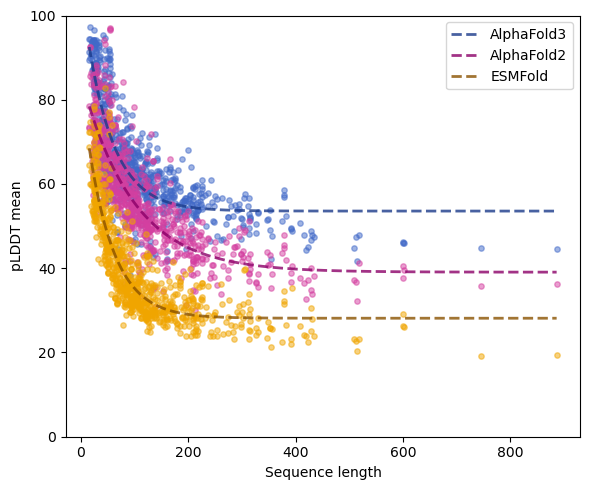

In [44]:
def equation(x, a, b, c):
    return a * np.exp(np.clip(-b * x, -709, 709)) + c


def plddt_sequence_length(esm, colabfold, af3, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    for df, model in [(af3, "AlphaFold3"), (colabfold, "AlphaFold2"), (esm, "ESMFold")]:
        mid = CURVE_COLOURS[model]["mid"]
        dark = CURVE_COLOURS[model]["dark"]
        ax.scatter(df["length"], df["pLDDT mean"], s=15, c=mid, alpha=0.5)
        data = df.sort_values("length").dropna(subset=["length", "pLDDT mean"])
        x_data = np.array(data["length"], dtype=np.float64)
        y_data = np.array(data["pLDDT mean"], dtype=np.float64)
        p, _ = curve_fit(equation, x_data, y_data)
        x = np.linspace(x_data.min(), x_data.max(), len(data))
        y_pred = equation(x_data, *p)
        r2 = 1 - np.sum((y_data - y_pred) ** 2) / np.sum((y_data - y_data.mean()) ** 2)
        ax.plot(
            x, equation(x, *p), "--", color=dark, alpha=0.8, linewidth=2, label=model
        )
        print(
            f"{model}: {df['pLDDT mean'].min():.2f}-{df['pLDDT mean'].max():.2f}  R²={r2:.3f}"
        )

    ax.set_xlabel("Sequence length")
    ax.set_ylabel("pLDDT mean")
    ax.set_yticks(np.linspace(0, 100, 6))
    ax.set_ylim(0, 100)
    ax.legend(loc="upper right")
    # ax.set_title(title)
    plt.tight_layout()
    plt.show()


plddt_sequence_length(df_esm, df_colabfold, df_af3, "AntiFam: pLDDT")


AlphaFold3 < 200: 0.03-0.75
AlphaFold3: 0.03-0.75
AlphaFold2 < 200: 0.03-0.79
AlphaFold2: 0.03-0.79
ESMFold < 200: 0.01-0.592
ESMFold: 0.01-0.592


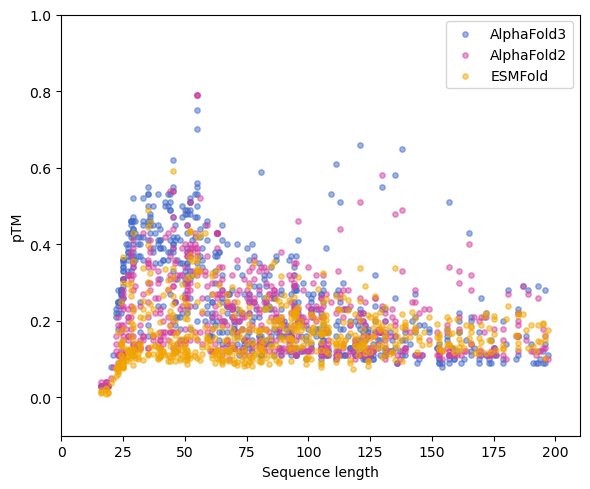

In [45]:
def combined_seq_ptm(esm, colabfold, af3, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    for df, model in [(af3, "AlphaFold3"), (colabfold, "AlphaFold2"), (esm, "ESMFold")]:
        short = df[df["length"] < 200]
        ax.scatter(
            short["length"],
            short["pTM"],
            s=15,
            c=CURVE_COLOURS[model]["mid"],
            alpha=0.5,
            label=model,
        )
        print(f"{model} < 200: {short['pTM'].min()}-{short['pTM'].max()}")
        print(f"{model}: {df['pTM'].min()}-{df['pTM'].max()}")
    ax.set_xlabel("Sequence length")
    ax.set_ylabel("pTM")
    ax.set_yticks(np.linspace(0, 1.0, 6))
    ax.set_xticks(range(0, 210, 25))
    ax.set_ylim(-0.1, 1.0)
    ax.set_xlim(0, 210)
    ax.legend(loc="upper right")
    # ax.set_title(title)
    plt.tight_layout()
    plt.show()


combined_seq_ptm(df_esm, df_colabfold, df_af3, "AntiFam: pTM")



All lengths
----------------------------------------------------------------------
AlphaFold3   n= 763  mean=65.15  sd=12.46  med=62.21
AlphaFold2   n= 763  mean=57.36  sd=12.74  med=55.79
ESMFold      n= 763  mean=39.82  sd=12.22  med=36.10

Independent t-tests (two-tailed):
  AlphaFold3 vs AlphaFold2   Δμ=  7.79, t= 12.065, p=0.0000 *** (d=0.618)
  AlphaFold2 vs ESMFold      Δμ= 17.54, t= 27.434, p=0.0000 *** (d=1.405)

Short (≤50 aa)
----------------------------------------------------------------------
AlphaFold3   n= 176  mean=80.74  sd=10.28  med=83.30
AlphaFold2   n= 176  mean=71.18  sd=8.55  med=70.13
ESMFold      n= 176  mean=56.30  sd=9.03  med=55.45

Independent t-tests (two-tailed):
  AlphaFold3 vs AlphaFold2   Δμ=  9.56, t=  9.456, p=0.0000 *** (d=1.011)
  AlphaFold2 vs ESMFold      Δμ= 14.88, t= 15.832, p=0.0000 *** (d=1.692)


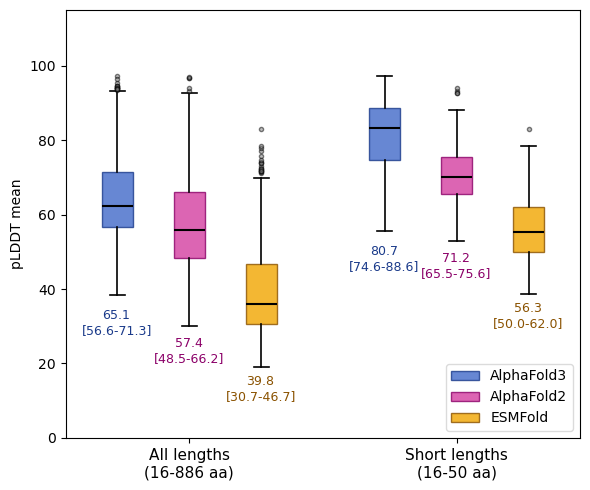

In [46]:
def plot_plddt_comparison(af2, af3, esm):
    comparisons = [
        ("AlphaFold3", "AlphaFold2"),
        ("AlphaFold2", "ESMFold"),
    ]
    model_colors = {
        k: (CURVE_COLOURS[k]["mid"], CURVE_COLOURS[k]["dark"])
        for k in ["AlphaFold3", "AlphaFold2", "ESMFold"]
    }
    models = list(model_colors.keys())

    df_groups = {
        "All lengths": (af3, af2, esm),
        "Short (≤50 aa)": (
            af3[af3["length"] <= 50],
            af2[af2["length"] <= 50],
            esm[esm["length"] <= 50],
        ),
    }

    groups = {
        gname: {m: df["pLDDT mean"].dropna().values for m, df in zip(models, dfs)}
        for gname, dfs in df_groups.items()
    }

    box_w, intra, inter = 0.3, 0.7, 2.6
    centres = [0, inter]
    positions = {
        g: [c + o for o in [-intra, 0, intra]] for g, c in zip(groups, centres)
    }

    for gname, (a3, a2, e) in df_groups.items():
        vals = groups[gname]
        print(f"\n{gname}")
        print("-" * 70)

        for m, v in vals.items():
            print(
                f"{m:<12} n={len(v):>4}  mean={v.mean():.2f}  sd={v.std():.2f}  med={np.median(v):.2f}"
            )

        # Independent t-tests (AF3 vs AF2, AF2 vs ESM)
        print("\nIndependent t-tests (two-tailed):")
        comparisons = [
            ("AlphaFold3", "AlphaFold2"),
            ("AlphaFold2", "ESMFold"),
        ]

        for m1, m2 in comparisons:
            v1, v2 = vals[m1], vals[m2]
            t_stat, p_val = stats.ttest_ind(v1, v2)
            mean_diff = v1.mean() - v2.mean()
            # Cohen's d
            pooled_sd = np.sqrt(
                ((len(v1) - 1) * v1.std() ** 2 + (len(v2) - 1) * v2.std() ** 2)
                / (len(v1) + len(v2) - 2)
            )
            cohens_d = mean_diff / pooled_sd

            sig = (
                "***"
                if p_val < 0.001
                else "**"
                if p_val < 0.01
                else "*"
                if p_val < 0.05
                else "ns"
            )
            print(
                f"  {m1} vs {m2:<12} Δμ={mean_diff:>6.2f}, t={t_stat:>7.3f}, p={p_val:.4f} {sig:<3} (d={cohens_d:.3f})"
            )

    fig, ax = plt.subplots(figsize=(6, 5))
    whisker_tops = {}

    for gname, vals in groups.items():
        for i, (model, pos) in enumerate(zip(models, positions[gname])):
            v = vals[model]
            mid, dark = model_colors[model]

            bp = ax.boxplot(
                [v],
                positions=[pos],
                widths=box_w,
                patch_artist=True,
                medianprops=dict(color="black", linewidth=1.5),
                whiskerprops=dict(color="black", linewidth=1.2),
                capprops=dict(color="black", linewidth=1.2),
                flierprops=dict(
                    marker="o", markerfacecolor="grey", markersize=3, alpha=0.5
                ),
            )
            bp["boxes"][0].set(facecolor=mid, edgecolor=dark, alpha=0.8)

            q1, q3 = np.percentile(v, [25, 75])
            iqr = q3 - q1
            wlo = max(v.min(), q1 - 1.5 * iqr)
            whi = min(v.max(), q3 + 1.5 * iqr)
            whisker_tops[(gname, model)] = whi

            ax.annotate(
                f"{v.mean():.1f}\n[{q1:.1f}-{q3:.1f}]",
                xy=(pos, wlo),
                xytext=(-0.5, -10 - i * -2),
                textcoords="offset points",
                ha="center",
                va="top",
                fontsize=9,
                color=dark,
            )

    all_l = pd.concat([af2["length"], af3["length"], esm["length"]]).dropna()
    short_l = all_l[all_l <= 50]

    ax.set_xticks(centres)
    ax.set_xticklabels(
        [
            f"All lengths\n({int(all_l.min())}-{int(all_l.max())} aa)",
            f"Short lengths\n({int(short_l.min())}-{int(short_l.max())} aa)",
        ],
        fontsize=11,
    )

    ax.set_xlim(centres[0] - 1.2, centres[-1] + 1.2)
    ax.set_ylabel("pLDDT mean")
    ax.set_ylim(0, 115)
    ax.set_yticks(np.linspace(0, 100, 6))

    ax.legend(
        handles=[
            mpatches.Patch(facecolor=mid, edgecolor=dark, alpha=0.8, label=m)
            for m, (mid, dark) in model_colors.items()
        ],
        loc="lower right",
        framealpha=0.7,
    )

    plt.tight_layout()
    plt.show()


plot_plddt_comparison(df_colabfold, df_af3, df_esm)


  All lengths
  AlphaFold3   n=763  mean=0.23  sd=0.13  med=0.20
  AlphaFold2   n=763  mean=0.20  sd=0.10  med=0.17
  ESMFold      n=763  mean=0.16  sd=0.07  med=0.15

  Short (≤50 aa)
  AlphaFold3   n=176  mean=0.35  sd=0.12  med=0.37
  AlphaFold2   n=176  mean=0.22  sd=0.11  med=0.18
  ESMFold      n=176  mean=0.16  sd=0.10  med=0.12


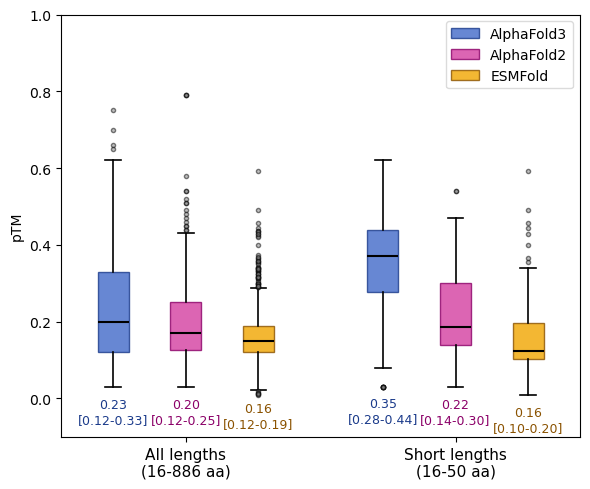

In [47]:
def plot_ptm_comparison(af2, af3, esm):
    model_colors = {
        k: (CURVE_COLOURS[k]["mid"], CURVE_COLOURS[k]["dark"])
        for k in ["AlphaFold3", "AlphaFold2", "ESMFold"]
    }
    models = list(model_colors.keys())

    groups = {
        "All lengths": {
            m: df["pTM"].dropna().values for m, df in zip(models, [af3, af2, esm])
        },
        "Short (≤50 aa)": {
            m: df[df["length"] <= 50]["pTM"].dropna().values
            for m, df in zip(models, [af3, af2, esm])
        },
    }
    box_w, intra, inter = 0.3, 0.7, 2.6
    centres = [0, inter]
    positions = {
        g: [c + o for o in [-intra, 0, intra]] for g, c in zip(groups, centres)
    }

    for gname, vals in groups.items():
        print(f"\n  {gname}")
        for m, v in vals.items():
            print(
                f"  {m:<12} n={len(v)}  mean={v.mean():.2f}  sd={v.std():.2f}  med={np.median(v):.2f}"
            )

    fig, ax = plt.subplots(figsize=(6, 5))
    for gname, vals in groups.items():
        for model, pos in zip(models, positions[gname]):
            v = vals[model]
            mid, dark = model_colors[model]
            bp = ax.boxplot(
                [v],
                positions=[pos],
                widths=box_w,
                patch_artist=True,
                medianprops=dict(color="black", linewidth=1.5),
                whiskerprops=dict(color="black", linewidth=1.2),
                capprops=dict(color="black", linewidth=1.2),
                flierprops=dict(
                    marker="o", markerfacecolor="grey", markersize=3, alpha=0.5
                ),
            )
            bp["boxes"][0].set(facecolor=mid, edgecolor=dark, alpha=0.8)
            q1, q3 = np.percentile(v, [25, 75])
            wlo = max(v.min(), q1 - 1.5 * (q3 - q1))
            ax.annotate(
                f"{v.mean():.2f}\n[{q1:.2f}-{q3:.2f}]",
                xy=(pos, wlo),
                xytext=(0, -8),
                textcoords="offset points",
                ha="center",
                va="top",
                fontsize=9,
                color=dark,
            )

    all_l = pd.concat([af2["length"], af3["length"], esm["length"]]).dropna()
    short_l = all_l[all_l <= 50]
    ax.set_xticks(centres)
    ax.set_xticklabels(
        [
            f"All lengths\n({int(all_l.min())}-{int(all_l.max())} aa)",
            f"Short lengths\n({int(short_l.min())}-{int(short_l.max())} aa)",
        ],
        fontsize=11,
    )
    ax.set_xlim(centres[0] - 1.2, centres[-1] + 1.2)
    ax.set_ylabel("pTM")
    ax.set_ylim(-0.1, 1)
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.legend(
        handles=[
            mpatches.Patch(facecolor=mid, edgecolor=dark, alpha=0.8, label=m)
            for m, (mid, dark) in model_colors.items()
        ],
        loc="upper right",
        framealpha=0.7,
    )
    plt.tight_layout()
    plt.show()


plot_ptm_comparison(df_colabfold, df_af3, df_esm)

AlphaFold3 pLDDT-pTM  p=6.0776e-93  se=0.0003  R²=0.423
AlphaFold2 pLDDT-pTM  p=6.7268e-63  se=0.0002  R²=0.308
ESMFold pLDDT-pTM  p=1.1575e-12  se=0.0002  R²=0.064


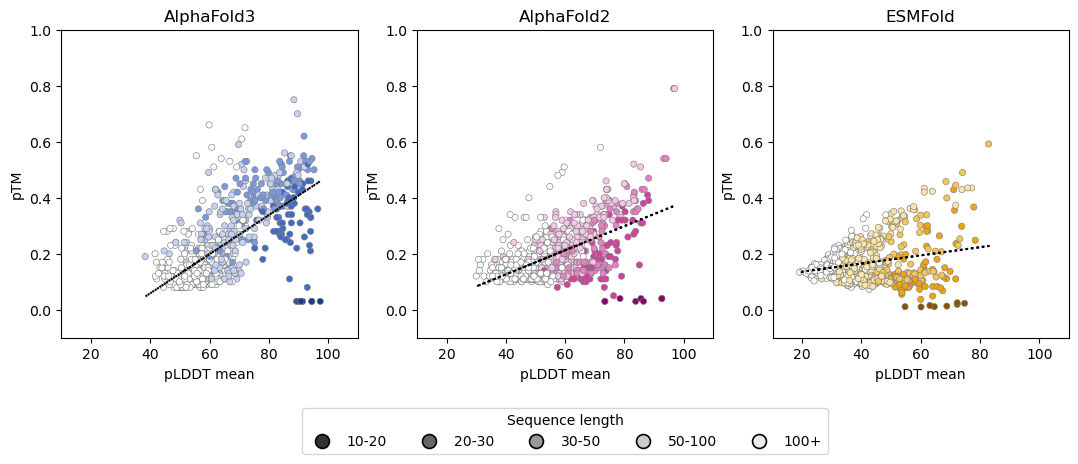

In [48]:
_LEN_BINS = [10, 20, 30, 50, 100, np.inf]
_LEN_LABELS = ["10-20", "20-30", "30-50", "50-100", "100+"]


def sub_scatter(ax, data, model_name, ptmtype="ptm"):
    colors = LENGTH_BIN_COLOURS[model_name]
    data = data.copy()
    data["length_bin"] = pd.cut(
        data["length"], bins=_LEN_BINS, labels=_LEN_LABELS, right=False
    )
    point_colors = data["length_bin"].map(dict(zip(_LEN_LABELS, colors)))

    y_col = "pae pTM" if ptmtype == "altptm" else "pTM"
    ax.scatter(
        data["pLDDT mean"],
        data[y_col],
        s=20,
        c=point_colors,
        edgecolors="grey",
        linewidth=0.45,
    )

    m, b = np.polyfit(data["pLDDT mean"], data[y_col], 1)
    ax.plot(
        data["pLDDT mean"],
        m * data["pLDDT mean"] + b,
        linestyle=":",
        lw=1.5,
        color="black",
    )

    slope, _, r_value, p_value, std_err = stats.linregress(
        data["pLDDT mean"], data[y_col]
    )
    print(
        f"{model_name} pLDDT-pTM  p={p_value:.4e}  se={std_err:.4f}  R²={r_value**2:.3f}"
    )

    ax.set_xlabel("pLDDT mean")
    ax.set_ylabel("pae pTM" if ptmtype == "altptm" else "pTM")
    ax.set_title(model_name)
    ax.set_yticks(np.linspace(0, 1.0, 6))
    ax.set_xticks(range(20, 110, 20))
    ax.set_xlim(10, 110)
    ax.set_ylim(-0.1, 1.0)


fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sub_scatter(axes[0], df_af3, "AlphaFold3")
sub_scatter(axes[1], df_colabfold, "AlphaFold2")
sub_scatter(axes[2], df_esm, "ESMFold")

grey_handles = [
    mlines.Line2D(
        [0],
        [0],
        marker="o",
        color="k",
        markerfacecolor=g,
        markeredgecolor="black",
        markeredgewidth=1.2,
        markersize=10,
        linestyle="None",
    )
    for g in ["#333333", "#666666", "#999999", "#cccccc", "#eeeeee"]
]
axes[2].legend(
    grey_handles,
    _LEN_LABELS,
    title="Sequence length",
    loc="lower center",
    bbox_to_anchor=(-0.70, -0.4),
    ncol=5,
    frameon=True,
)

plt.show()

# Fig 2 - combined

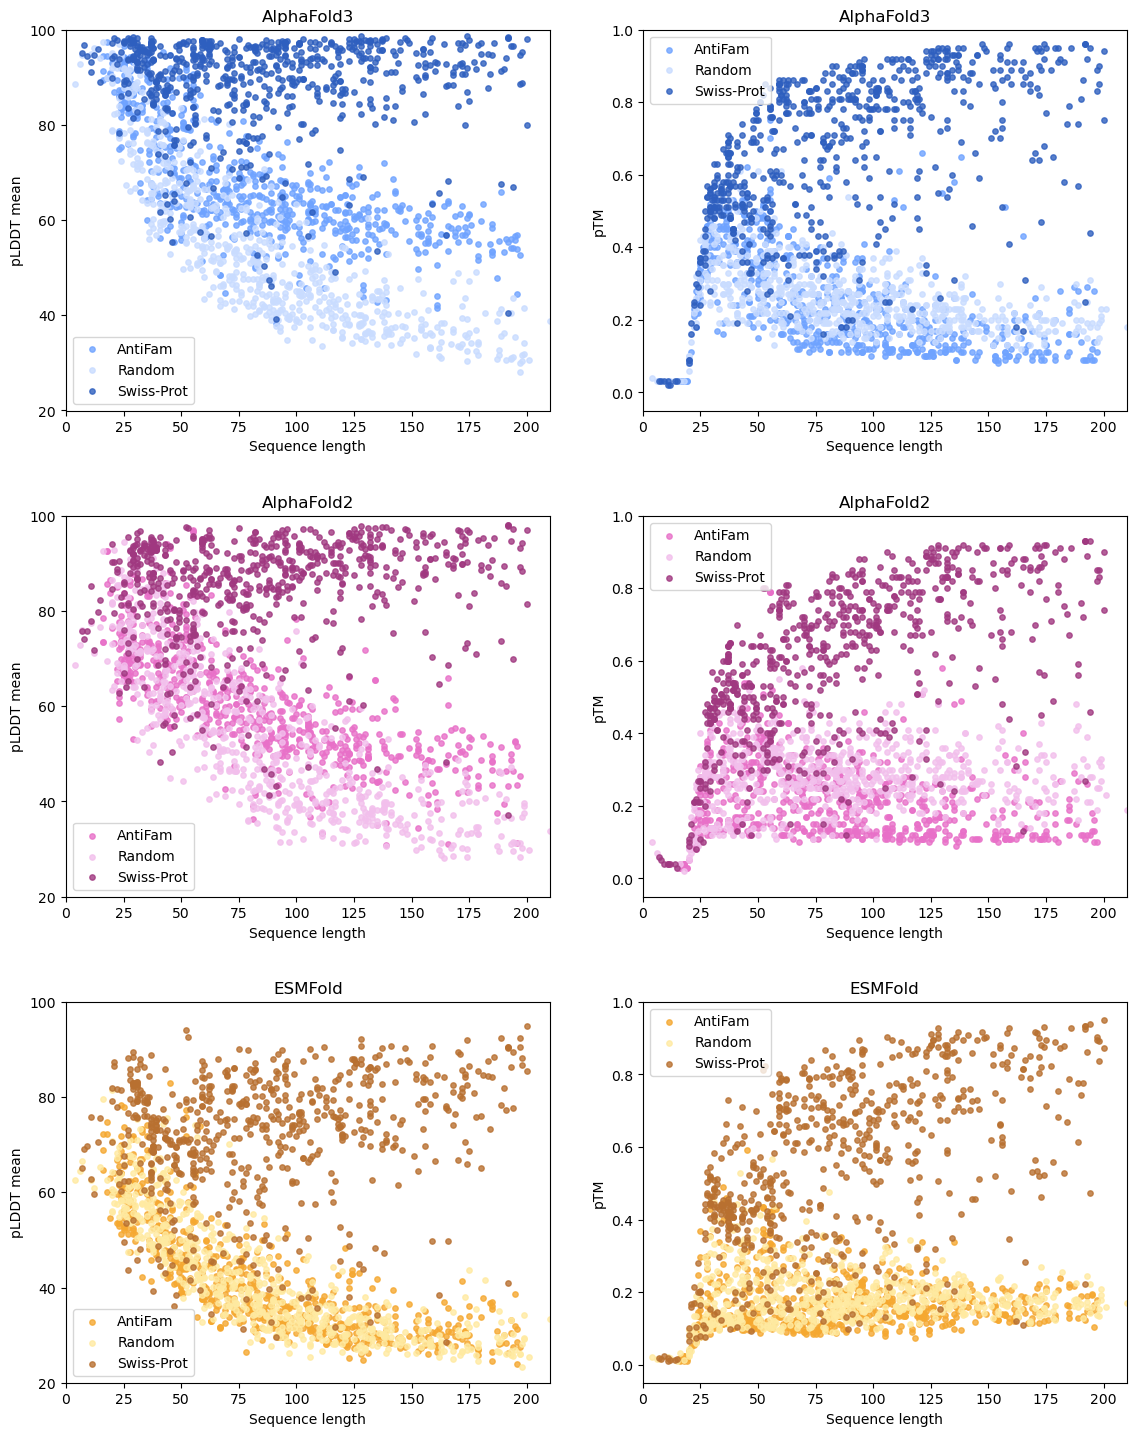

In [49]:
def plot_pLDDT(ax, antifam_df, random_df, swissprot_df, model_name, size=15, alpha=0.8):
    colors = COLOUR_MAP[model_name]
    short_af = antifam_df[antifam_df["length"] < 200]
    for df, key in [
        (short_af, "AntiFam"),
        (random_df, "Random"),
        (swissprot_df, "Swiss-Prot"),
    ]:
        ax.scatter(
            df["length"],
            df["pLDDT mean"],
            label=key,
            s=size,
            c=colors[key],
            alpha=alpha,
        )
    ax.set_ylabel("pLDDT mean")
    ax.set_xlabel("Sequence length")
    ax.set_yticks(np.linspace(20, 100, 5))
    ax.set_ylim(20, 100)
    ax.set_xlim(0, 210)
    ax.set_xticks(range(0, 210, 25))
    ax.set_title(model_name)


def plot_pTM(
    ax,
    antifam_df,
    random_df,
    swissprot_df,
    model_name,
    ptm_type="pTM",
    size=15,
    alpha=0.8,
):
    colors = COLOUR_MAP[model_name]
    short_af = antifam_df[antifam_df["length"] < 200]
    for df, key in [
        (short_af, "AntiFam"),
        (random_df, "Random"),
        (swissprot_df, "Swiss-Prot"),
    ]:
        ax.scatter(
            df["length"], df[ptm_type], label=key, s=size, c=colors[key], alpha=alpha
        )
    ax.set_ylabel(ptm_type)
    ax.set_xlabel("Sequence length")
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.set_ylim(-0.05, 1)
    ax.set_xlim(0, 210)
    ax.set_xticks(range(0, 210, 25))
    ax.set_title(model_name)


def plot_all_comparisons(
    af2_data, af3_data, esm_data, ptm_type="pTM", figsize=(12, 15)
):
    fig, axes = plt.subplots(3, 2, figsize=figsize)
    for row, (data, name) in enumerate(
        [(af3_data, "AlphaFold3"), (af2_data, "AlphaFold2"), (esm_data, "ESMFold")]
    ):
        af, rd, sp = data
        plot_pLDDT(axes[row, 0], af, rd, sp, name)
        plot_pTM(axes[row, 1], af, rd, sp, name, ptm_type=ptm_type)
        axes[row, 0].legend(loc="lower left")
        axes[row, 1].legend(loc="upper left")
    plt.tight_layout(pad=3.0)
    plt.show()


plot_all_comparisons(
    af2_data=(df_colabfold, wrdm_colabfold, sp_colabfold),
    af3_data=(df_af3, wrdm_af3, sp_af3),
    esm_data=(df_esm, wrdm_esm, sp_esm),
    ptm_type="pTM",
)


pLDDT mean | AntiFam | AlphaFold3: mean=65.148, IQR=[56.579-71.344], range=[38.284-97.348], n=763
pLDDT mean | AntiFam | AlphaFold2: mean=57.361, IQR=[48.453-66.164], range=[30.014-96.920], n=763
pLDDT mean | AntiFam | ESMFold: mean=39.816, IQR=[30.700-46.700], range=[19.100-82.900], n=763
pLDDT mean | Random | AlphaFold3: mean=55.130, IQR=[41.182-66.483], range=[28.187-97.460], n=644
pLDDT mean | Random | AlphaFold2: mean=54.018, IQR=[39.862-66.231], range=[28.096-94.455], n=644
pLDDT mean | Random | ESMFold: mean=42.066, IQR=[32.225-50.525], range=[23.300-81.500], n=644
pLDDT mean | Swiss-Prot | AlphaFold3: mean=89.286, IQR=[86.541-95.907], range=[39.231-98.586], n=644
pLDDT mean | Swiss-Prot | AlphaFold2: mean=85.467, IQR=[81.415-92.907], range=[37.171-98.050], n=644
pLDDT mean | Swiss-Prot | ESMFold: mean=72.218, IQR=[66.200-81.825], range=[28.600-94.900], n=644
pTM | AntiFam | AlphaFold3: mean=0.234, IQR=[0.120-0.330], range=[0.030-0.750], n=763
pTM | AntiFam | AlphaFold2: mean=0.

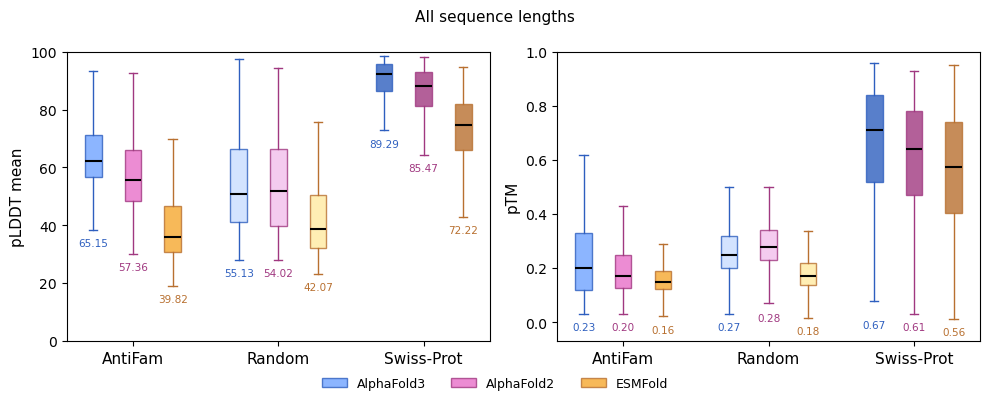

pLDDT mean | AntiFam | AlphaFold3: mean=80.737, IQR=[74.637-88.623], range=[55.493-97.348], n=176
pLDDT mean | AntiFam | AlphaFold2: mean=71.181, IQR=[65.479-75.560], range=[53.034-94.092], n=176
pLDDT mean | AntiFam | ESMFold: mean=56.302, IQR=[49.950-62.000], range=[38.800-82.900], n=176
pLDDT mean | Random | AlphaFold3: mean=77.702, IQR=[67.772-88.109], range=[52.877-97.460], n=170
pLDDT mean | Random | AlphaFold2: mean=72.292, IQR=[64.859-78.893], range=[44.999-94.455], n=170
pLDDT mean | Random | ESMFold: mean=57.655, IQR=[52.025-62.600], range=[41.700-81.500], n=170
pLDDT mean | Swiss-Prot | AlphaFold3: mean=90.195, IQR=[87.282-95.688], range=[55.444-98.366], n=170
pLDDT mean | Swiss-Prot | AlphaFold2: mean=84.282, IQR=[79.563-92.613], range=[48.335-96.708], n=170
pLDDT mean | Swiss-Prot | ESMFold: mean=70.556, IQR=[64.450-78.975], range=[36.100-89.400], n=170
pTM | AntiFam | AlphaFold3: mean=0.353, IQR=[0.278-0.440], range=[0.030-0.620], n=176
pTM | AntiFam | AlphaFold2: mean=0.

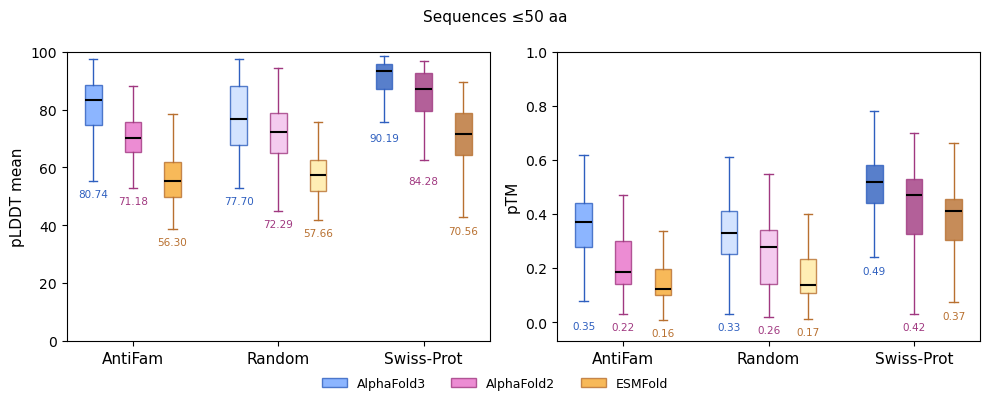

In [50]:
def plot_confidence_boxplots(
    af2_data, af3_data, esm_data, ptm_type="pTM", length_threshold=None
):
    models = ["AlphaFold3", "AlphaFold2", "ESMFold"]
    data_map = {
        "AlphaFold3": af3_data,
        "AlphaFold2": af2_data,
        "ESMFold": esm_data,
    }
    groups = ["AntiFam", "Random", "Swiss-Prot"]
    metrics = ["pLDDT mean", ptm_type]
    y_configs = {
        "pLDDT mean": {"ylim": (-0.07, 100), "yticks": np.linspace(0, 100, 6)},
        ptm_type: {"ylim": (-0.07, 1), "yticks": np.linspace(0, 1, 6)},
    }

    box_w, intra, inter = 0.25, 0.6, 2.2
    group_centres = [i * inter for i in range(len(groups))]
    model_offsets = [-intra, 0, intra]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    if length_threshold is not None:
        fig.suptitle(f"Sequences ≤{length_threshold} aa", fontsize=11)
    else:
        fig.suptitle("All sequence lengths", fontsize=11)

    for ax, metric in zip(axes, metrics):
        for g_idx, group in enumerate(groups):
            for m_idx, model in enumerate(models):
                antifam_df, random_df, swissprot_df = data_map[model]
                df_map = {
                    "AntiFam": antifam_df,
                    "Random": random_df,
                    "Swiss-Prot": swissprot_df,
                }
                df = df_map[group]

                if length_threshold is not None:
                    df = df[df["length"] <= length_threshold]

                v = df[metric].dropna().values

                pos = group_centres[g_idx] + model_offsets[m_idx]
                mid = COLOUR_MAP[model][group]
                dark = COLOUR_MAP[model]["Swiss-Prot"]

                bp = ax.boxplot(
                    [v],
                    positions=[pos],
                    widths=box_w,
                    patch_artist=True,
                    showfliers=False,
                    medianprops=dict(color="black", linewidth=1.5),
                    whiskerprops=dict(color=dark, linewidth=1.0),
                    capprops=dict(color=dark, linewidth=1.0),
                )
                bp["boxes"][0].set(facecolor=mid, edgecolor=dark, alpha=0.8)

                q1, q3 = np.percentile(v, [25, 75])
                iqr = q3 - q1
                wlo = max(v.min(), q1 - 1.5 * iqr)

                print(
                    f"{metric} | {group} | {model}: "
                    f"mean={v.mean():.3f}, IQR=[{q1:.3f}-{q3:.3f}], "
                    f"range=[{v.min():.3f}-{v.max():.3f}], n={len(v)}"
                )

                ax.annotate(
                    f"{v.mean():.2f}",
                    xy=(pos, wlo),
                    xytext=(0, -6),
                    textcoords="offset points",
                    ha="center",
                    va="top",
                    fontsize=7.5,
                    color=dark,
                )

        ax.set_xticks(group_centres)
        ax.set_xticklabels(groups, fontsize=11)
        ax.set_xlim(group_centres[0] - 1.0, group_centres[-1] + 1.0)
        ax.set_ylabel(metric, fontsize=11)
        ax.set_ylim(y_configs[metric]["ylim"])
        ax.set_yticks(y_configs[metric]["yticks"])
        # _style_ax(ax)

    handles = [
        mpatches.Patch(
            facecolor=COLOUR_MAP[m]["AntiFam"],
            edgecolor=COLOUR_MAP[m]["Swiss-Prot"],
            alpha=0.8,
            label=m,
        )
        for m in models
    ]
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=len(models),
        fontsize=9,
        bbox_to_anchor=(0.5, 0),
        frameon=False,
    )
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()


plot_confidence_boxplots(
    af2_data=(df_colabfold, wrdm_colabfold, sp_colabfold),
    af3_data=(df_af3, wrdm_af3, sp_af3),
    esm_data=(df_esm, wrdm_esm, sp_esm),
    ptm_type="pTM",
)

plot_confidence_boxplots(
    af2_data=(df_colabfold, wrdm_colabfold, sp_colabfold),
    af3_data=(df_af3, wrdm_af3, sp_af3),
    esm_data=(df_esm, wrdm_esm, sp_esm),
    ptm_type="pTM",
    length_threshold=50,
)

pLDDT mean | AntiFam | AlphaFold3: mean=80.737, IQR=[74.637-88.623], range=[55.493-97.348], n=176
pLDDT mean | AntiFam | AlphaFold2: mean=71.181, IQR=[65.479-75.560], range=[53.034-94.092], n=176
pLDDT mean | AntiFam | ESMFold: mean=56.302, IQR=[49.950-62.000], range=[38.800-82.900], n=176
pLDDT mean | Random | AlphaFold3: mean=77.702, IQR=[67.772-88.109], range=[52.877-97.460], n=170
pLDDT mean | Random | AlphaFold2: mean=72.292, IQR=[64.859-78.893], range=[44.999-94.455], n=170
pLDDT mean | Random | ESMFold: mean=57.655, IQR=[52.025-62.600], range=[41.700-81.500], n=170
pLDDT mean | Swiss-Prot | AlphaFold3: mean=90.195, IQR=[87.282-95.688], range=[55.444-98.366], n=170
pLDDT mean | Swiss-Prot | AlphaFold2: mean=84.282, IQR=[79.563-92.613], range=[48.335-96.708], n=170
pLDDT mean | Swiss-Prot | ESMFold: mean=70.556, IQR=[64.450-78.975], range=[36.100-89.400], n=170
pTM | AntiFam | AlphaFold3: mean=0.353, IQR=[0.278-0.440], range=[0.030-0.620], n=176
pTM | AntiFam | AlphaFold2: mean=0.

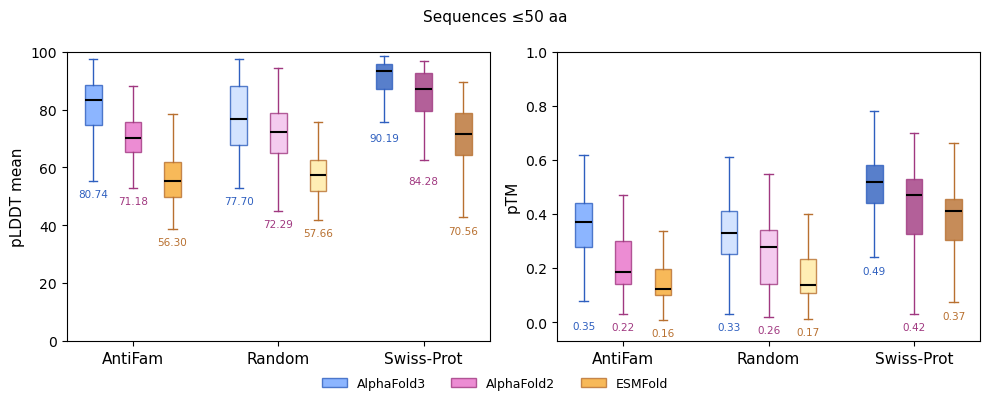

In [51]:
plot_confidence_boxplots(
    af2_data=(df_colabfold, wrdm_colabfold, sp_colabfold),
    af3_data=(df_af3, wrdm_af3, sp_af3),
    esm_data=(df_esm, wrdm_esm, sp_esm),
    ptm_type="pTM",
    length_threshold=50,
)

In [52]:
print("confident swissprots pLDDT")
print("AF3:", len(sp_af3[sp_af3["pLDDT mean"] > 70]) / len(sp_af3))
print("AF2:", len(sp_colabfold[sp_colabfold["pLDDT mean"] > 70]) / len(sp_af3))
print("ESMFold:", len(sp_esm[sp_esm["pLDDT mean"] > 70]) / len(sp_esm))

print("pTM", len(sp_af3))
print("AF3:", len(sp_af3[sp_af3["pTM"] > 0.5]) / len(sp_af3))
print("AF2:", len(sp_colabfold[sp_colabfold["pTM"] > 0.5]) / len(sp_af3))
print("ESMFold:", len(sp_esm[sp_esm["pTM"] > 0.5]) / len(sp_esm))

longer_af3 = sp_af3[sp_af3["length"] > 50]
longer_colabfold = sp_colabfold[sp_colabfold["length"] > 50]
longer_esm = sp_esm[sp_esm["length"] > 50]

print("pTM >50", len(longer_af3))
print("AF3:", len(longer_af3[longer_af3["pTM"] > 0.5]) / len(longer_af3))
print(
    "AF2:", len(longer_colabfold[longer_colabfold["pTM"] > 0.5]) / len(longer_colabfold)
)
print("ESMFold:", len(longer_esm[longer_esm["pTM"] > 0.5]) / len(longer_esm))

confident swissprots pLDDT
AF3: 0.9409937888198758
AF2: 0.9083850931677019
ESMFold: 0.656832298136646
pTM 644
AF3: 0.7795031055900621
AF2: 0.6832298136645962
ESMFold: 0.5854037267080745
pTM >50 474
AF3: 0.8502109704641351
AF2: 0.8080168776371308
ESMFold: 0.7362869198312236


In [53]:
SP_INFO_COLS = [
    "name",
    "iupred_average",
    "is_bacteria",
    "Pfam count",
    "MobiDB count",
    "caution",
    "annotation_score",
    "protein_existence_score",
]

sp_af3 = sp_af3.merge(
    sp_info[SP_INFO_COLS], left_index=True, right_on="uniprot_id", how="left"
)
sp_colabfold = sp_colabfold.merge(
    sp_info[SP_INFO_COLS], left_index=True, right_on="uniprot_id", how="left"
)
sp_esm = sp_esm.merge(
    sp_info[SP_INFO_COLS], left_index=True, right_on="uniprot_id", how="left"
)


In [54]:
low_conf_af3 = sp_af3[sp_af3["pLDDT mean"] < 50]
total = len(low_conf_af3)
print(total)
for label, mask in [
    (
        "Uncertain existence (5)",
        low_conf_af3["protein_existence_score"] == "5: Uncertain",
    ),
    ("Has caution flag", low_conf_af3["caution"].notna()),
    ("MobiDB count > 0", low_conf_af3["MobiDB count"] > 0),
    ("Pfam count > 0", low_conf_af3["Pfam count"] > 0),
    (
        "Existence score 1",
        low_conf_af3["protein_existence_score"] == "1: Evidence at protein level",
    ),
    (
        "Existence score 2",
        low_conf_af3["protein_existence_score"] == "2: Evidence at transcript level",
    ),
]:
    n = mask.sum()
    print(f"{label:<30} {n:>4}  ({100 * n / total:.1f}%)")

print(low_conf_af3)


5
Uncertain existence (5)           2  (40.0%)
Has caution flag                  2  (40.0%)
MobiDB count > 0                  2  (40.0%)
Pfam count > 0                    1  (20.0%)
Existence score 1                 0  (0.0%)
Existence score 2                 1  (20.0%)
            length  pLDDT mean   pTM  max pae   mean pae  pae pTM      method  \
uniprot_id                                                                      
O29555          89   46.178202  0.20     31.1  20.653263      NaN  AlphaFold3   
P0DJI1          88   47.485682  0.18     31.1  20.777557      NaN  AlphaFold3   
P40490         117   49.070256  0.23     31.7  23.357017      NaN  AlphaFold3   
A0A023PXK2     192   40.392396  0.25     31.4  22.134169      NaN  AlphaFold3   
Q99166          91   39.231319  0.20     30.5  18.862239      NaN  AlphaFold3   

                                                         name  iupred_average  \
uniprot_id                                                                      

In [55]:
low_conf_af2 = sp_colabfold[sp_colabfold["pLDDT mean"] < 50]
total = len(low_conf_af2)
print(total)
for label, mask in [
    (
        "Uncertain existence (5)",
        low_conf_af2["protein_existence_score"] == "5: Uncertain",
    ),
    ("Has caution flag", low_conf_af2["caution"].notna()),
    ("MobiDB count > 0", low_conf_af2["MobiDB count"] > 0),
    ("Pfam count > 0", low_conf_af2["Pfam count"] > 0),
    (
        "Existence score 1",
        low_conf_af2["protein_existence_score"] == "1: Evidence at protein level",
    ),
    (
        "Existence score 2",
        low_conf_af2["protein_existence_score"] == "2: Evidence at transcript level",
    ),
]:
    n = mask.sum()
    print(f"{label:<30} {n:>4}  ({100 * n / total:.1f}%)")

print(low_conf_af2)


9
Uncertain existence (5)           2  (22.2%)
Has caution flag                  2  (22.2%)
MobiDB count > 0                  2  (22.2%)
Pfam count > 0                    2  (22.2%)
Existence score 1                 1  (11.1%)
Existence score 2                 3  (33.3%)
            length  pLDDT mean   pTM    max pae   mean pae   pae pTM  \
uniprot_id                                                             
P0DJI1          88   41.316023  0.12  30.937500  21.073461  0.075352   
Q99166          91   43.193297  0.33  30.281250  17.912055  0.239915   
Q9GZY1         135   46.805407  0.24  30.718750  20.172239  0.171691   
Q93WP8         165   48.367818  0.13  31.296875  25.661793  0.100108   
O83592          41   48.335366  0.13  28.890625  17.091023  0.076041   
Q6B0Z2         105   47.268381  0.25  30.796875  20.921889  0.183033   
O29555          89   45.725618  0.21  31.187500  21.669759  0.151005   
A6YR40          86   46.850698  0.22  30.687500  19.240698  0.169264   
A0A023PX

In [56]:
low_conf_esm = sp_esm[sp_esm["pLDDT mean"] < 50]
total = len(low_conf_esm)
print(total)
for label, mask in [
    (
        "Uncertain existence (5)",
        low_conf_esm["protein_existence_score"] == "5: Uncertain",
    ),
    ("Has caution flag", low_conf_esm["caution"].notna()),
    ("MobiDB count > 0", low_conf_esm["MobiDB count"] > 0),
    ("Pfam count > 0", low_conf_esm["Pfam count"] > 0),
    (
        "Existence score 1",
        low_conf_esm["protein_existence_score"] == "1: Evidence at protein level",
    ),
    (
        "Existence score 2",
        low_conf_esm["protein_existence_score"] == "2: Evidence at transcript level",
    ),
]:
    n = mask.sum()
    print(f"{label:<30} {n:>4}  ({100 * n / total:.1f}%)")

print(low_conf_esm)


55
Uncertain existence (5)           6  (10.9%)
Has caution flag                 10  (18.2%)
MobiDB count > 0                  8  (14.5%)
Pfam count > 0                   28  (50.9%)
Existence score 1                10  (18.2%)
Existence score 2                11  (20.0%)
            length  pLDDT mean    pTM  max pae  mean pae pae pTM   method  \
uniprot_id                                                                  
A0A023PXK2     192        40.9  0.221      NaN       NaN       0  ESMFold   
A0A023W0U0      78        47.0  0.199      NaN       NaN       0  ESMFold   
A0A1D0BR67     119        45.5  0.319      NaN       NaN       0  ESMFold   
A0A1W2PPG7     107        39.4  0.213      NaN       NaN       0  ESMFold   
A0ZZ55          55        44.3  0.206      NaN       NaN       0  ESMFold   
A4GYV5          45        47.6  0.167      NaN       NaN       0  ESMFold   
A4H222         123        48.8  0.258      NaN       NaN       0  ESMFold   
A5DP59         127        45.0  0.

In [57]:
# get low scoring swissprot proteins pLDDT <= average AntiFam pLDDT
# combine for esmfold, alphafold3, alphafold2 (same df with scores for each - but note where they come from, one row per method), then get fasta sequences

model_results = [
    ("AlphaFold3", df_af3, sp_af3),
    ("AlphaFold2", wrdm_colabfold, sp_colabfold),
    ("ESMFold", wrdm_esm, sp_esm),
]

records = []

for model_name, af_df, sp_df in model_results:
    # threshold = mean of AntiFam mean pLDDTs for this model
    af_threshold = af_df["pLDDT mean"].mean()
    print(f"{model_name} AntiFam mean pLDDT threshold: {af_threshold:.2f}")

    # Swiss-Prot sequences below that threshold
    low_sp = sp_df[sp_df["pLDDT mean"] <= af_threshold].copy()
    low_sp["model"] = model_name
    low_sp["antifam_threshold"] = af_threshold
    records.append(low_sp)

df_low_sp = pd.concat(records).reset_index()
df_low_sp = df_low_sp.rename(columns={"index": "uniprot_id"})

print(f"\nTotal low-scoring Swiss-Prot entries: {len(df_low_sp)}")
print(df_low_sp.groupby("model")[["uniprot_id"]].count())
print(df_low_sp)


def load_fasta(fasta_path):
    return {rec.id: rec for rec in SeqIO.parse(fasta_path, "fasta")}


sp_fasta = load_fasta("../1_sequence_selection/sequences/swissprot_seqs/sp_seqs.fasta")

#collect all unique low-scoring seq IDs across all models
all_low_ids = set(df_low_sp["uniprot_id"].unique())

found = [sp_fasta[sid] for sid in all_low_ids if sid in sp_fasta]
missing = all_low_ids - set(sp_fasta.keys())

if missing:
    print(f"Warning: {len(missing)} IDs not found in FASTA: {missing}")

SeqIO.write(found, "low_plddt_swissprot.fasta", "fasta")
print(f"Wrote {len(found)} unique sequences to low_plddt_swissprot.fasta")

AlphaFold3 AntiFam mean pLDDT threshold: 65.15
AlphaFold2 AntiFam mean pLDDT threshold: 54.02
ESMFold AntiFam mean pLDDT threshold: 42.07

Total low-scoring Swiss-Prot entries: 59
            uniprot_id
model                 
AlphaFold2          13
AlphaFold3          23
ESMFold             23
    uniprot_id  length  pLDDT mean    pTM    max pae   mean pae   pae pTM  \
0       B3EWQ2      44   63.446136  0.470  18.200000   5.521539       NaN   
1       Q2QNC3      78   57.215000  0.160  31.600000  21.257692       NaN   
2       Q90WW1     159   63.301950  0.410  31.700000  22.198742       NaN   
3   A0A1W2PPG7     107   61.660654  0.250  31.700000  21.631356       NaN   
4       A4GYV5      45   60.188444  0.280  29.400000  13.875802       NaN   
5       A6YR40      86   50.413140  0.180  31.600000  21.465035       NaN   
6       Q8BCV7      83   52.608193  0.370  30.800000  14.607011       NaN   
7       Q06057      63   56.667778  0.350  30.400000  16.264701       NaN   
8       Q6B0

In [58]:
# annotate shadow res
shadow_res = pd.read_csv("low_sp_results/shadow_res_summary.tsv", sep="\t")

# merge onto df_low_sp by uniprot_id (keep df_low_sp rows where no shadow_res match)
df_low_sp = df_low_sp.merge(
    shadow_res[["uniprot_id", "frameshift_score", "shadow_score"]],
    on="uniprot_id",
    how="left",
)

unique_proteins = df_low_sp.drop_duplicates(subset="uniprot_id")
n_unique = len(unique_proteins)
print(f"Total unique Swiss-Prot proteins: {n_unique}")
df_low_sp.to_csv("low_sp_results/low_sp_anno.tsv", sep="\t")


Total unique Swiss-Prot proteins: 33


In [59]:
# # How many have caution flag (known potentially not real)?
# cautioned = unique_proteins[unique_proteins["caution"].notna()]
# print(f"\nProteins with caution flag: {len(cautioned)}")
# print(cautioned[["uniprot_id", "caution", "protein_existence_score"]])


# # How many have shadow / frameshift score?
# has_shadow = unique_proteins[
#     unique_proteins["uniprot_id"].isin(shadow_res["uniprot_id"])
# ]

# has_frameshift = has_shadow[has_shadow["frameshift_score"] < 0]
# has_shadow_score = has_shadow[has_shadow["shadow_score"] < 0]
# has_either = has_shadow[
#     (has_shadow["frameshift_score"] < 0) | (has_shadow["shadow_score"] < 0)
# ]

# print("\nProteins with shadow/frameshift score:")
# print(f"  - frameshift score < 0:        {len(has_frameshift)}")
# print(f"  - shadow score < 0:            {len(has_shadow_score)}")
# print(f"  - either score < 0:            {len(has_either)}")
# print(f"  - of which have caution flag:  {has_either['caution'].notna().sum()}")
# print(
#     has_either[
#         [
#             "uniprot_id",
#             "length",
#             "pLDDT mean",
#             "is_bacteria",
#             "caution",
#             "protein_existence_score",
#             "Pfam count",
#             "shadow_score",
#             "frameshift_score",
#         ]
#     ]
# )

In [60]:
# AntiFam mean pLDDT per method
antifam_mean_af3 = df_af3["pLDDT mean"].mean()
antifam_mean_af2 = df_colabfold["pLDDT mean"].mean()
antifam_mean_esm = df_esm["pLDDT mean"].mean()

# Swiss-Prot proteins below AntiFam mean pLDDT per method
low_af3 = set(sp_af3[sp_af3["pLDDT mean"] < antifam_mean_af3].index)
low_af2 = set(sp_colabfold[sp_colabfold["pLDDT mean"] < antifam_mean_af2].index)
low_esm = set(sp_esm[sp_esm["pLDDT mean"] < antifam_mean_esm].index)

all_low = low_af3 | low_af2 | low_esm
shared_all_three = low_af3 & low_af2 & low_esm
shared_af3_af2 = low_af3 & low_af2
shared_af3_esm = low_af3 & low_esm
shared_af2_esm = low_af2 & low_esm

print("Below AntiFam mean pLDDT:")
print(f"  AlphaFold3:         {len(low_af3)}")
print(f"  AlphaFold2:         {len(low_af2)}")
print(f"  ESMFold:            {len(low_esm)}")
print(f"  Unique total:       {len(all_low)}")
print(f"  Shared all three:   {len(shared_all_three)}")
print(f"  Shared AF3+AF2:     {len(shared_af3_af2)}")
print(f"  Shared AF3+ESM:     {len(shared_af3_esm)}")
print(f"  Shared AF2+ESM:     {len(shared_af2_esm)}")

print(shared_all_three)

Below AntiFam mean pLDDT:
  AlphaFold3:         23
  AlphaFold2:         18
  ESMFold:            20
  Unique total:       36
  Shared all three:   9
  Shared AF3+AF2:     13
  Shared AF3+ESM:     12
  Shared AF2+ESM:     9
{'P40490', 'Q93WP8', 'Q99166', 'O29555', 'Q2QNC3', 'P0DJI1', 'P0DSG2', 'Q6B0Z2', 'Q9GZY1'}


In [61]:
# print(df_low_sp[df_low_sp["shadow_score"].isna()]["uniprot_id"].unique())

In [62]:
def get_auroc_shade(auroc):
    if np.isnan(auroc):
        return "#F8F8F8"
    if auroc <= 0.05:
        return AUROC_COLOURS["<= 0.05"]
    if auroc <= 0.10:
        return AUROC_COLOURS["<= 0.10"]
    if auroc <= 0.25:
        return AUROC_COLOURS["<= 0.25"]
    return AUROC_COLOURS[">  0.25"]


def compute_auroc(a, b):
    stat, _ = mannwhitneyu(a, b, alternative="less")
    return stat / (len(a) * len(b))


def compute_bin_stats(antifam_df, swissprot_df, feature="pLDDT mean"):
    rows = []
    for i in range(len(BINS) - 1):
        lo, hi = BINS[i], BINS[i + 1]
        af = antifam_df[(antifam_df["length"] >= lo) & (antifam_df["length"] < hi)][
            feature
        ].dropna()
        sp = swissprot_df[
            (swissprot_df["length"] >= lo) & (swissprot_df["length"] < hi)
        ][feature].dropna()
        row = dict(
            center=(lo + hi) / 2,
            label=BIN_LABELS[i],
            width=hi - lo,
            n_af=len(af),
            n_sp=len(sp),
            af_vals=af,
            sp_vals=sp,
            ovl=np.nan,
            auroc=np.nan,
        )
        if len(af) >= 5 and len(sp) >= 5:
            row["auroc"] = compute_auroc(af.values, sp.values)
            try:
                kde_af, kde_sp = gaussian_kde(af), gaussian_kde(sp)
                ovl, _ = quad(
                    lambda x: float(min(kde_af(x)[0], kde_sp(x)[0])),
                    min(af.min(), sp.min()),
                    max(af.max(), sp.max()),
                )
                row["ovl"] = float(ovl)
            except Exception:
                pass
        rows.append(row)
    return pd.DataFrame(rows)


In [63]:
def plot_oc_separation(antifam_df, swissprot_df, model_name, feature="pLDDT mean"):
    af_color = COLOUR_MAP[model_name]["AntiFam"]
    sp_color = COLOUR_MAP[model_name]["Swiss-Prot"]

    df = compute_bin_stats(antifam_df, swissprot_df, feature)
    valid_bins = df.dropna(subset=["ovl"])
    n_bins = len(valid_bins)
    if n_bins == 0:
        print(f"[{model_name}] No bins with n>=5 in both groups.")
        return df

    fig = plt.figure(figsize=(12, 6))
    fig.suptitle(model_name, fontsize=13)

    outer = fig.add_gridspec(
        2,
        1,
        height_ratios=[4, 1],
        hspace=0.25,
    )

    # TOP PANEL (KDE plots)
    ncols = min(5, n_bins)
    nrows = int(np.ceil(n_bins / ncols))

    gs_top = outer[0].subgridspec(
        nrows,
        ncols,
        hspace=0.75,
        wspace=0.35,
    )

    xs = np.linspace(0, 100, 200)
    xtick_vals = np.arange(0, 101, 20)

    for idx, (_, row) in enumerate(valid_bins.iterrows()):
        r, c = divmod(idx, ncols)
        ax = fig.add_subplot(gs_top[r, c])

        kde_af = gaussian_kde(row["af_vals"])
        kde_sp = gaussian_kde(row["sp_vals"])
        y_af, y_sp = kde_af(xs), kde_sp(xs)

        ax.plot(xs, y_af, color=af_color, linewidth=1.2)
        ax.plot(xs, y_sp, color=sp_color, linewidth=1.2)
        ax.fill_between(xs, np.minimum(y_af, y_sp), color="grey", alpha=0.5)

        ax.set_ylim(0.0, 0.16)
        ax.set_yticks(np.linspace(0.0, 0.15, 4))

        # auroc_str = f"{row['auroc']:.2f}" if not np.isnan(row["auroc"]) else "—"
        ax.set_title(
            f"{row['label']} aa\n(AF {len(row['af_vals'])}, SP {len(row['sp_vals'])})",  # \nOC {row['ovl']:.2f}, AUROC {auroc_str}",
            fontsize=9,
            pad=3,
        )

        if c == 0:
            ax.set_ylabel("Density", fontsize=8)
        else:
            ax.set_ylabel("")  # remove label, keep ticks

        ax.tick_params(axis="y", labelsize=5.5)

        ax.set_xlim(0, 100)
        ax.set_xticks(xtick_vals)
        ax.set_xticklabels([f"{v:.0f}" for v in xtick_vals], fontsize=7)
        ax.set_xlabel(feature, fontsize=9)

        fig.legend(
            handles=[
                mpatches.Patch(color=af_color, label="AntiFam"),
                mpatches.Patch(color=sp_color, label="Swiss-Prot"),
                mpatches.Patch(color="grey", alpha=0.5, label="Overlap"),
            ],
            loc="upper right",
            bbox_to_anchor=(1.02, 0.90),
            fontsize=9,
            # frameon=False,
        )

    # BOTTOM PANEL (OC bar plot)
    gs_bot = outer[1].subgridspec(1, 1)
    ax2 = fig.add_subplot(gs_bot[0])

    ax2.bar(
        df["center"],
        df["ovl"],
        width=df["width"].values * 0.8,
        color=[get_auroc_shade(a) for a in df["auroc"]],
        alpha=0.9,
        edgecolor="white",
        linewidth=0.5,
    )

    ax2.set_ylim(0, 1)
    ax2.set_ylabel("Overlapping\ncoefficient", fontsize=9)
    ax2.set_xlabel("Sequence length (residues)", fontsize=10)

    ax2.set_xticks(df["center"])
    ax2.set_xticklabels(df["label"], rotation=0, ha="center", fontsize=9)
    ax2.tick_params(axis="y", labelsize=9)

    auroc_handles = [
        mpatches.Patch(color=v, alpha=0.9, label=f"AUROC {k}")
        for k, v in reversed(list(AUROC_COLOURS.items()))
    ]

    ax2.legend(
        handles=auroc_handles,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        # frameon=False,
    )

    plt.show()
    return df


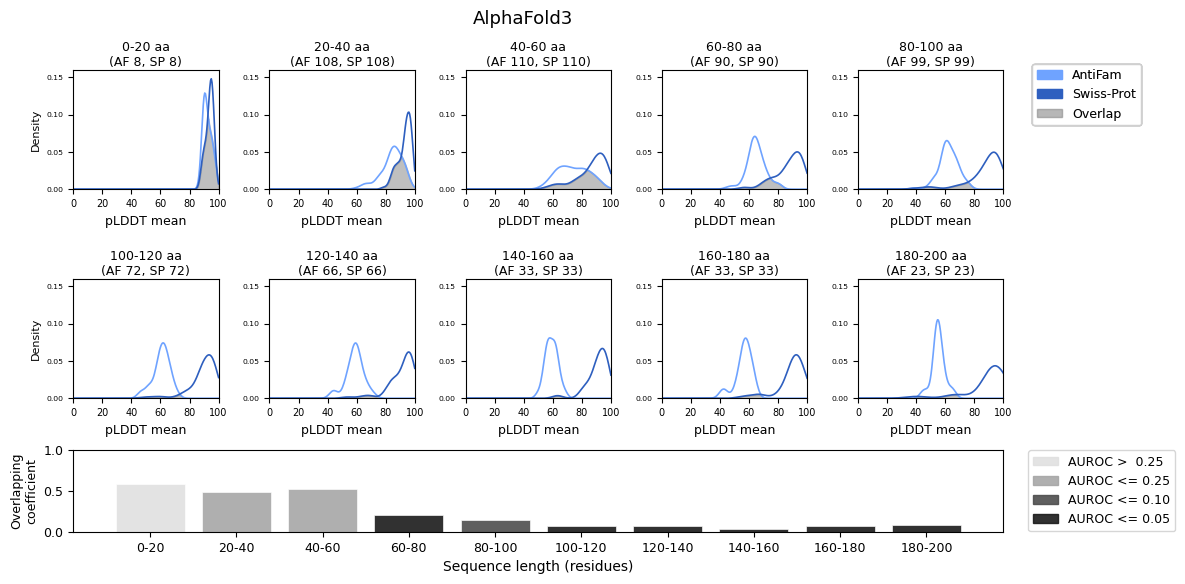

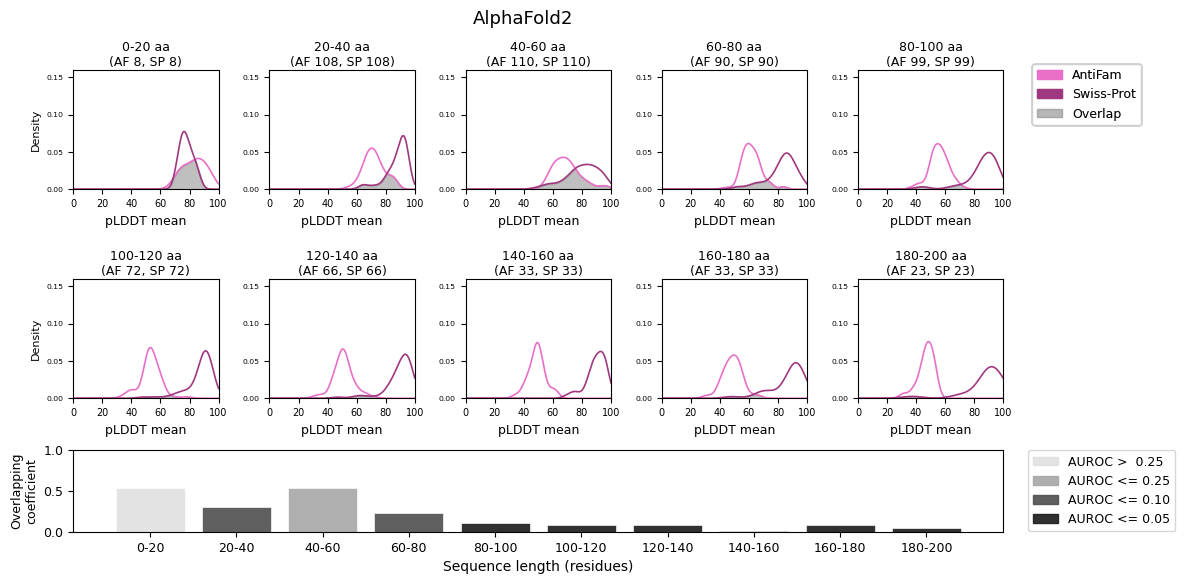

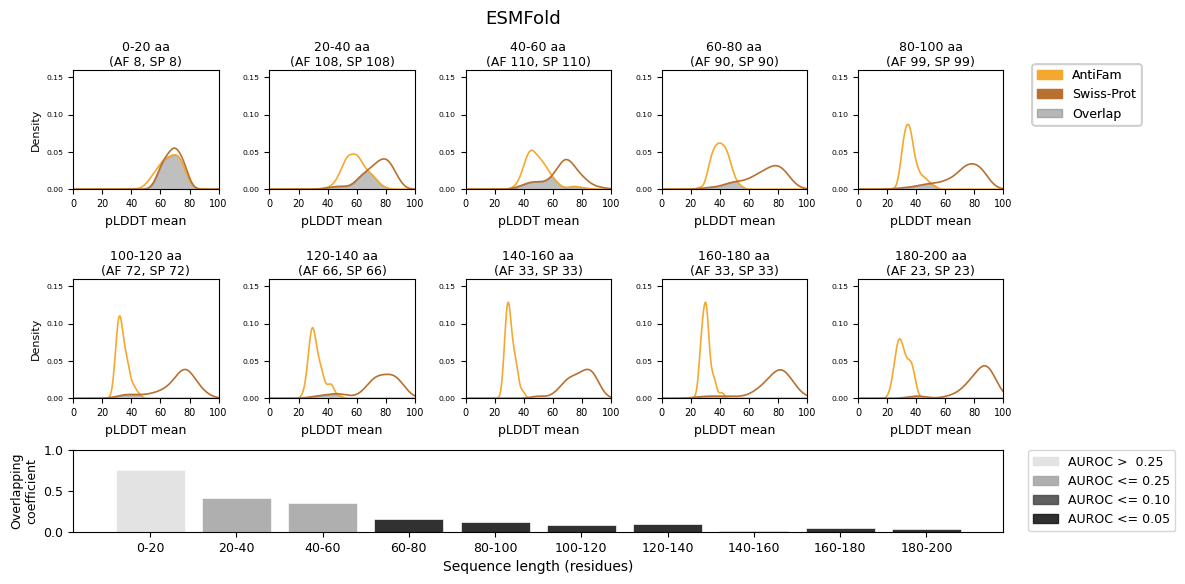

In [64]:
for af_df, sp_df, name in [
    (df_af3, sp_af3, "AlphaFold3"),
    (df_colabfold, sp_colabfold, "AlphaFold2"),
    (df_esm, sp_esm, "ESMFold"),
]:
    plot_oc_separation(af_df, sp_df, name)

In [65]:
# LABEL_SIZE = 13
# TICK_SIZE = 12

# # Control subplot width ratio here
# WIDTH_RATIOS = [2, 1]  # scatter plot : boxplot


# def plot_plddt_combined(esm, colabfold, af3):
#     fig, (ax1, ax2) = plt.subplots(
#         1,
#         2,
#         figsize=(9, 5),
#         gridspec_kw={"width_ratios": WIDTH_RATIOS},
#     )

#     # --- Scatter + trend lines ---
#     for df, model in [(af3, "AlphaFold3"), (colabfold, "AlphaFold2"), (esm, "ESMFold")]:
#         mid = CURVE_COLOURS[model]["mid"]
#         dark = CURVE_COLOURS[model]["dark"]
#         ax1.scatter(df["length"], df["pLDDT mean"], s=15, c=mid, alpha=0.5)
#         data = df.sort_values("length").dropna(subset=["length", "pLDDT mean"])
#         x_data = np.array(data["length"], dtype=np.float64)
#         y_data = np.array(data["pLDDT mean"], dtype=np.float64)
#         p, _ = curve_fit(equation, x_data, y_data)
#         x = np.linspace(x_data.min(), x_data.max(), len(data))
#         y_pred = equation(x_data, *p)
#         r2 = 1 - np.sum((y_data - y_pred) ** 2) / np.sum((y_data - y_data.mean()) ** 2)
#         ax1.plot(
#             x, equation(x, *p), "--", color=dark, alpha=0.8, linewidth=2, label=model
#         )
#         print(
#             f"{model}: {df['pLDDT mean'].min():.2f}-{df['pLDDT mean'].max():.2f}  R²={r2:.3f}"
#         )

#     ax1.set_xlabel("Sequence length", fontsize=LABEL_SIZE)
#     ax1.set_ylabel("pLDDT mean", fontsize=LABEL_SIZE)
#     ax1.set_yticks(np.linspace(0, 100, 3))
#     ax1.set_ylim(0, 100)
#     ax1.tick_params(axis="both", labelsize=TICK_SIZE)
#     ax1.legend(loc="upper right", fontsize=TICK_SIZE, frameon=False)
#     # ax1.set_title("AntiFam: pLDDT", fontsize=LABEL_SIZE)
#     ax1.spines[["top", "right"]].set_visible(False)

#     # --- Boxplots ---
#     model_colors = {
#         k: (CURVE_COLOURS[k]["mid"], CURVE_COLOURS[k]["dark"])
#         for k in ["AlphaFold3", "AlphaFold2", "ESMFold"]
#     }
#     models = list(model_colors.keys())

#     df_groups = {
#         "Short (≤50 aa)": (
#             af3[af3["length"] <= 50],
#             colabfold[colabfold["length"] <= 50],
#             esm[esm["length"] <= 50],
#         ),
#         "All lengths": (af3, colabfold, esm),
#     }

#     groups = {
#         gname: {m: df["pLDDT mean"].dropna().values for m, df in zip(models, dfs)}
#         for gname, dfs in df_groups.items()
#     }

#     box_w, intra, inter = 0.3, 0.7, 2.6
#     centres = [0, inter]
#     positions = {
#         g: [c + o for o in [-intra, 0, intra]] for g, c in zip(groups, centres)
#     }

#     for gname, vals in groups.items():
#         for model, pos in zip(models, positions[gname]):
#             v = vals[model]
#             mid, dark = model_colors[model]
#             bp = ax2.boxplot(
#                 [v],
#                 positions=[pos],
#                 widths=box_w,
#                 patch_artist=True,
#                 medianprops=dict(color="black", linewidth=1.5),
#                 whiskerprops=dict(color="black", linewidth=1.2),
#                 capprops=dict(color="black", linewidth=1.2),
#                 flierprops=dict(
#                     marker="o", markerfacecolor="grey", markersize=3, alpha=0.5
#                 ),
#             )
#             bp["boxes"][0].set(facecolor=mid, edgecolor=dark, alpha=0.8)

#     all_l = pd.concat([colabfold["length"], af3["length"], esm["length"]]).dropna()
#     short_l = all_l[all_l <= 50]

#     ax2.set_xticks(centres)
#     ax2.set_xticklabels(
#         [
#             f"Short lengths\n({int(short_l.min())}-{int(short_l.max())} aa)",
#             f"All lengths\n({int(all_l.min())}-{int(all_l.max())} aa)",
#         ],
#         fontsize=TICK_SIZE,
#     )
#     ax2.set_xlim(centres[0] - 1.2, centres[-1] + 1.2)
#     ax2.set_ylabel("pLDDT mean", fontsize=LABEL_SIZE)
#     ax2.set_ylim(0, 115)
#     ax2.set_yticks(np.linspace(0, 100, 3))
#     ax2.tick_params(axis="both", labelsize=TICK_SIZE)
#     ax2.spines[["top", "right"]].set_visible(False)
#     ax2.legend(
#         handles=[
#             mpatches.Patch(facecolor=mid, edgecolor=dark, alpha=0.8, label=m)
#             for m, (mid, dark) in model_colors.items()
#         ],
#         loc="lower left",
#         fontsize=TICK_SIZE,
#         frameon=False,
#     )

#     plt.tight_layout()
#     plt.show()


# plot_plddt_combined(df_esm, df_colabfold, df_af3)

In [66]:
# BINS = [0, 50, 100, 200]
# BIN_LABELS = [f"{BINS[i]}-{BINS[i + 1]}" for i in range(len(BINS) - 1)]

# LABEL_SIZE = 13
# TICK_SIZE = 12


# def plot_all_oc_separation(model_data, feature="pLDDT mean"):
#     n_models = len(model_data)
#     n_bins = 3
#     xs = np.linspace(0, 100, 200)
#     xtick_vals = [0, 50, 100]

#     fig, axes = plt.subplots(
#         n_models,
#         n_bins,
#         figsize=(2 * n_bins + 2, 2.5 * n_models),
#         sharey=True,
#     )

#     for row, (model_name, af_df, sp_df) in enumerate(model_data):
#         af_color = COLOUR_MAP[model_name]["AntiFam"]
#         sp_color = COLOUR_MAP[model_name]["Swiss-Prot"]

#         df = compute_bin_stats(af_df, sp_df, feature)
#         valid_bins = df.dropna(subset=["ovl"])

#         for col, (_, bin_row) in enumerate(valid_bins.iterrows()):
#             ax = axes[row][col]

#             kde_af = gaussian_kde(bin_row["af_vals"])
#             kde_sp = gaussian_kde(bin_row["sp_vals"])
#             y_af = kde_af(xs)
#             y_sp = kde_sp(xs)

#             ax.plot(xs, y_af, color=af_color, linewidth=4)
#             ax.plot(xs, y_sp, color=sp_color, linewidth=4)
#             ax.fill_between(xs, np.minimum(y_af, y_sp), color="grey", alpha=0.5)

#             ax.spines[["top", "right"]].set_visible(False)

#             ax.set_ylim(0.0, 0.12)
#             ax.set_yticks(np.linspace(0.0, 0.1, 3))
#             ax.tick_params(axis="y", length=4, width=1, labelsize=TICK_SIZE)

#             ax.set_xlim(0, 100)
#             ax.set_xticks(xtick_vals)
#             ax.tick_params(axis="x", length=4, width=1)

#             if row == n_models - 1:
#                 ax.set_xticklabels([str(v) for v in xtick_vals], fontsize=TICK_SIZE)
#                 ax.set_xlabel(feature, fontsize=LABEL_SIZE)
#             else:
#                 ax.set_xticklabels([])
#                 ax.set_xlabel("")

#             if row == 0:
#                 ax.set_title(
#                     f"{bin_row['label']} aa\n(AF {len(bin_row['af_vals'])}, SP {len(bin_row['sp_vals'])})",
#                     fontsize=LABEL_SIZE,
#                     pad=8,
#                 )

#             if col == 0:
#                 ax.set_ylabel(f"{model_name}\nDensity", fontsize=LABEL_SIZE)
#             else:
#                 ax.set_ylabel("")
#                 ax.tick_params(axis="y", length=4, labelsize=0)

#             # Stacked labels at fixed positions in top-left of middle column only
#             if col == 1:
#                 for i, (label, color) in enumerate(
#                     [
#                         ("AntiFam", af_color),
#                         ("Swiss-Prot", sp_color),
#                         ("Overlap", "grey"),
#                     ]
#                 ):
#                     ax.text(
#                         0.05,
#                         0.95 - i * 0.18,
#                         label,
#                         transform=ax.transAxes,
#                         color=color,
#                         fontsize=TICK_SIZE,
#                         fontweight="bold",
#                         ha="left",
#                         va="top",
#                     )

#     plt.tight_layout()
#     plt.savefig("oc_separation_all_models.png", dpi=150, bbox_inches="tight")
#     plt.show()


# plot_all_oc_separation(
#     [
#         ("AlphaFold3", df_af3, sp_af3),
#         ("AlphaFold2", df_colabfold, sp_colabfold),
#         ("ESMFold", df_esm, sp_esm),
#     ]
# )

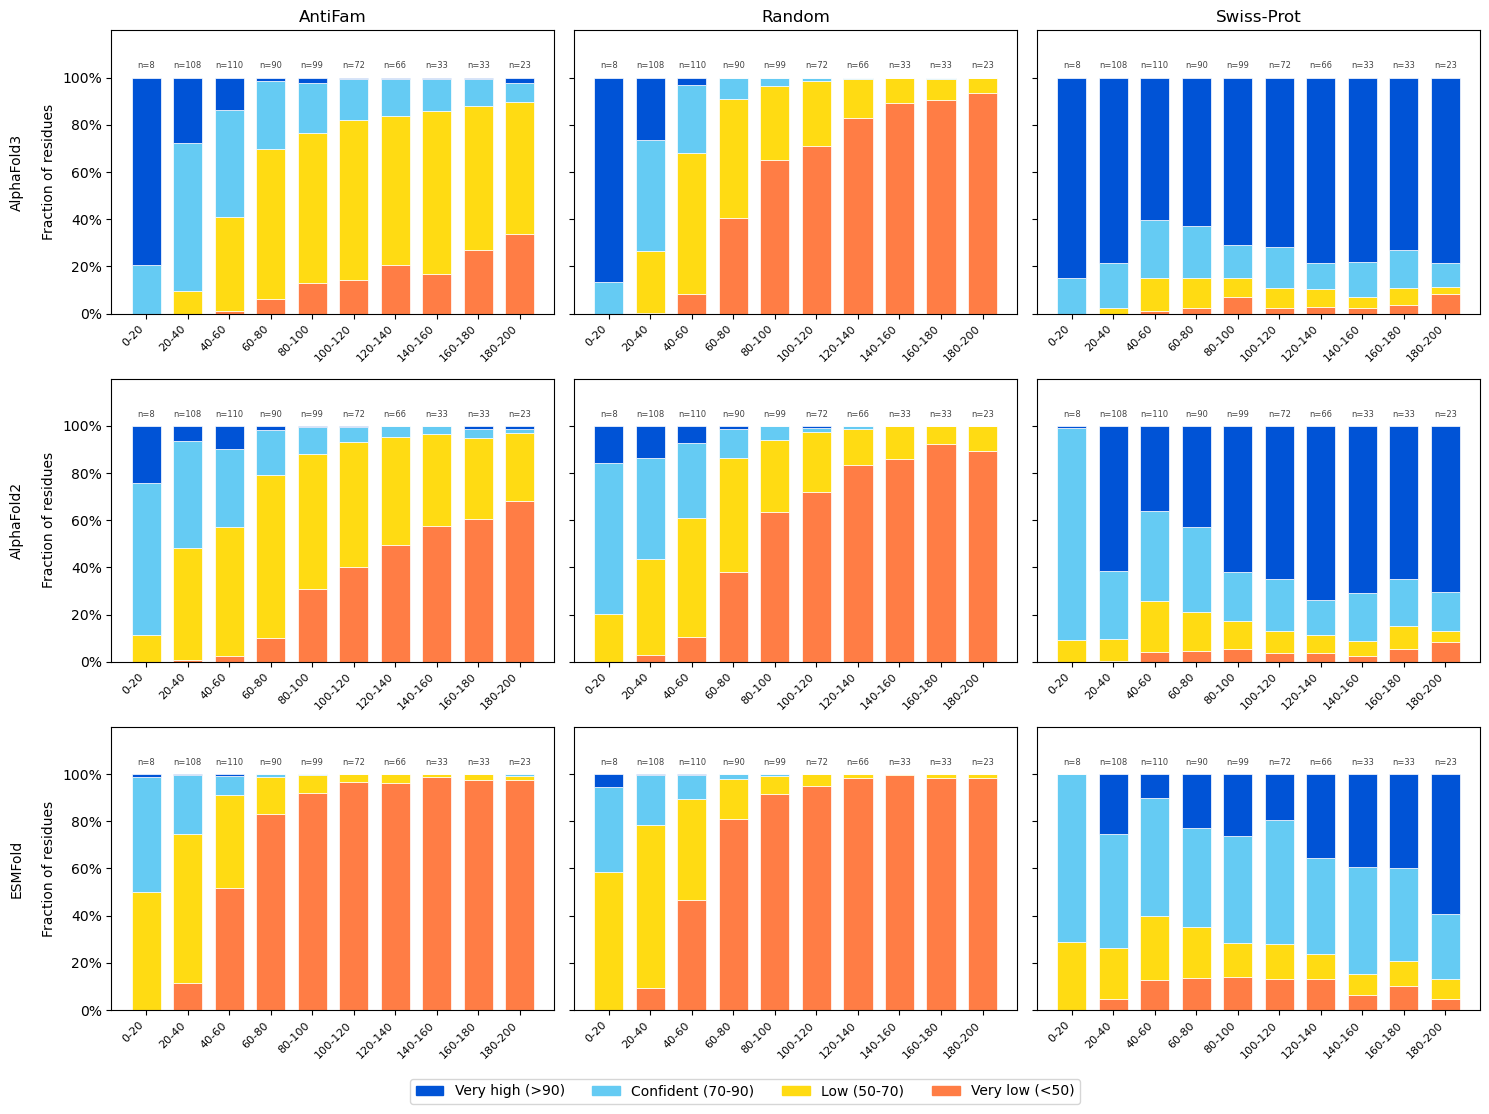


AntiFam
    bin  count  total
   0-20      8    763
  20-40    108    763
  40-60    110    763
  60-80     90    763
 80-100     99    763
100-120     72    763
120-140     66    763
140-160     33    763
160-180     33    763
180-200     23    763

Random
    bin  count  total
   0-20      8    644
  20-40    108    644
  40-60    110    644
  60-80     90    644
 80-100     99    644
100-120     72    644
120-140     66    644
140-160     33    644
160-180     33    644
180-200     23    644

Swiss-Prot
    bin  count  total
   0-20      8    644
  20-40    108    644
  40-60    110    644
  60-80     90    644
 80-100     99    644
100-120     72    644
120-140     66    644
140-160     33    644
160-180     33    644
180-200     23    644


In [67]:
BINS = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
BIN_LABELS = [f"{BINS[i]}-{BINS[i + 1]}" for i in range(len(BINS) - 1)]


def plot_plddt_fractions_combined(models):
    cats = ["Very high (>90)", "Confident (70-90)", "Low (50-70)", "Very low (<50)"]

    def load_plddt(path):
        with open(path) as f:
            return json.load(f)

    def get_fractions(df, plddt_data):
        rows = []
        for lo, hi in zip(BINS, BINS[1:]):
            seq_ids = df[(df["length"] >= lo) & (df["length"] < hi)].index
            all_res = []
            for sid in seq_ids:
                if sid in plddt_data:
                    vals = [
                        v for v in plddt_data[sid] if v is not None and not np.isnan(v)
                    ]
                    all_res.extend(vals)

            n_seq = len(seq_ids)
            n_res = len(all_res)

            if n_res == 0:
                rows.append({c: np.nan for c in cats} | {"n_seq": 0, "n_res": 0})
            else:
                arr = np.array(all_res)
                rows.append(
                    {
                        "Very high (>90)": (arr >= 90).sum() / n_res,
                        "Confident (70-90)": ((arr >= 70) & (arr < 90)).sum() / n_res,
                        "Low (50-70)": ((arr >= 50) & (arr < 70)).sum() / n_res,
                        "Very low (<50)": (arr < 50).sum() / n_res,
                        "n_seq": n_seq,
                        "n_res": n_res,
                    }
                )
        return pd.DataFrame(rows, index=BIN_LABELS)

    def get_protein_stats(df, plddt_data):
        records = []
        for sid in df.index:
            if sid not in plddt_data:
                continue
            vals = [v for v in plddt_data[sid] if v is not None and not np.isnan(v)]
            if not vals:
                continue
            arr = np.array(vals)
            records.append(
                {
                    "seq_id": sid,
                    "mean_plddt": arr.mean(),
                    "sd_plddt": arr.std(
                        ddof=1
                    ), 
                    "n_res": len(arr),
                }
            )
        return pd.DataFrame(records).set_index("seq_id")

    fig, axes = plt.subplots(
        nrows=len(models), ncols=3, figsize=(15, 4 * len(models)), sharey=True
    )
    if len(models) == 1:
        axes = axes[np.newaxis, :]

    group_names = ["AntiFam", "Random", "Swiss-Prot"]
    protein_stats = {}

    for row_idx, (
        af_df,
        rd_df,
        sp_df,
        af_path,
        rd_path,
        sp_path,
        model_name,
    ) in enumerate(models):
        plddt_af = load_plddt(af_path)
        plddt_rd = load_plddt(rd_path)
        plddt_sp = load_plddt(sp_path)

        protein_stats[model_name] = {}

        for col_idx, (gname, df, plddt_data) in enumerate(
            [
                (group_names[0], af_df, plddt_af),
                (group_names[1], rd_df, plddt_rd),
                (group_names[2], sp_df, plddt_sp),
            ]
        ):
            ax = axes[row_idx, col_idx]
            fracs = get_fractions(df, plddt_data)
            protein_stats[model_name][gname] = get_protein_stats(df, plddt_data)

            bottoms = np.zeros(len(fracs))

            for cat in reversed(cats):
                vals = fracs[cat].fillna(0).values
                ax.bar(
                    range(len(fracs)),
                    vals,
                    bottom=bottoms,
                    color=PLDDT_COLOURS[cat],
                    width=0.7,
                    edgecolor="white",
                    linewidth=0.5,
                )
                bottoms += vals

            for j, (_, row) in enumerate(fracs.iterrows()):
                if row["n_seq"] > 0:
                    ax.text(
                        j,
                        1.03,
                        f"n={int(row['n_seq'])}",
                        ha="center",
                        va="bottom",
                        fontsize=6,
                        color="#444444",
                    )

            ax.set_xticks(range(len(BIN_LABELS)))
            ax.set_xticklabels(BIN_LABELS, rotation=45, ha="right", fontsize=8)

            if row_idx == 0:
                ax.set_title(gname, fontsize=12)
            if col_idx == 0:
                ax.set_ylabel(f"{model_name}\n\nFraction of residues", fontsize=10)

            ax.set_ylim(0, 1.2)
            ax.set_yticks(np.linspace(0, 1, 6))
            ax.set_yticklabels([f"{int(v * 100)}%" for v in np.linspace(0, 1, 6)])

    handles = [mpatches.Patch(color=PLDDT_COLOURS[c], label=c) for c in cats]
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=4,
        fontsize=10,
        bbox_to_anchor=(0.5, 0.02),
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

    return protein_stats


protein_stats = plot_plddt_fractions_combined(
    [
        (
            df_af3,
            wrdm_af3,
            sp_af3,
            PLDDT_PATHS["AlphaFold3"]["AntiFam"],
            PLDDT_PATHS["AlphaFold3"]["Random"],
            PLDDT_PATHS["AlphaFold3"]["Swiss-Prot"],
            "AlphaFold3",
        ),
        (
            df_colabfold,
            wrdm_colabfold,
            sp_colabfold,
            PLDDT_PATHS["AlphaFold2"]["AntiFam"],
            PLDDT_PATHS["AlphaFold2"]["Random"],
            PLDDT_PATHS["AlphaFold2"]["Swiss-Prot"],
            "AlphaFold2",
        ),
        (
            df_esm,
            wrdm_esm,
            sp_esm,
            PLDDT_PATHS["ESMFold"]["AntiFam"],
            PLDDT_PATHS["ESMFold"]["Random"],
            PLDDT_PATHS["ESMFold"]["Swiss-Prot"],
            "ESMFold",
        ),
    ]
)
for gname, df in [("AntiFam", df_af3), ("Random", wrdm_af3), ("Swiss-Prot", sp_af3)]:
    counts = []
    for lo, hi in zip(BINS, BINS[1:]):
        n = ((df["length"] >= lo) & (df["length"] < hi)).sum()
        counts.append(n)
    print(f"\n{gname}")
    print(
        pd.DataFrame(
            {"bin": BIN_LABELS, "count": counts, "total": [len(df)] * len(counts)}
        ).to_string(index=False)
    )

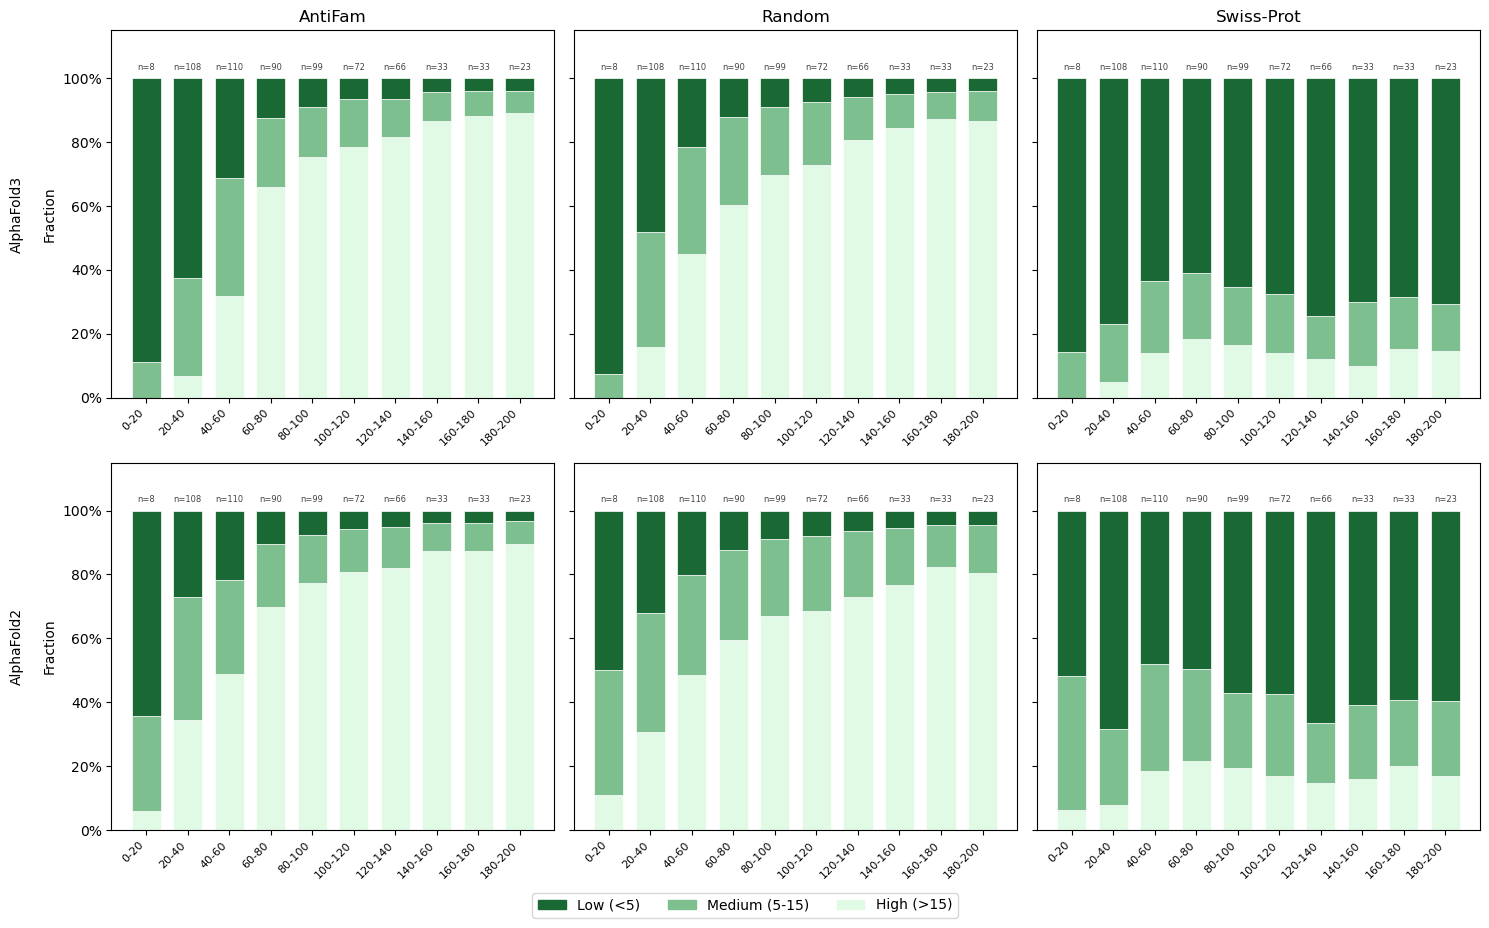

In [68]:
def plot_pae_fractions_combined(models):
    """
    models = [
        (df_af3, wrdm_af3, sp_af3,
         PAE_PATHS["AlphaFold3"]["AntiFam"],
         PAE_PATHS["AlphaFold3"]["Random"],
         PAE_PATHS["AlphaFold3"]["Swiss-Prot"],
         "AlphaFold3"),

        (df_colabfold, wrdm_colabfold, sp_colabfold,
         PAE_PATHS["AlphaFold2"]["AntiFam"],
         PAE_PATHS["AlphaFold2"]["Random"],
         PAE_PATHS["AlphaFold2"]["Swiss-Prot"],
         "AlphaFold2"),
    ]
    """
    pae_cats = ["Low (<5)", "Medium (5-15)", "High (>15)"]

    def get_fractions(len_df, pae_dict):
        rows = []
        for lo, hi in zip(BINS, BINS[1:]):
            ids = len_df[(len_df["length"] >= lo) & (len_df["length"] < hi)].index
            vals = np.concatenate(
                [np.array(pae_dict[i]).flatten() for i in ids if i in pae_dict],
                dtype=float,
            )
            n = len(ids)
            if len(vals) == 0:
                rows.append(
                    {
                        "Low (<5)": np.nan,
                        "Medium (5-15)": np.nan,
                        "High (>15)": np.nan,
                        "n": 0,
                    }
                )
            else:
                rows.append(
                    {
                        "Low (<5)": (vals < 5).mean(),
                        "Medium (5-15)": ((vals >= 5) & (vals <= 15)).mean(),
                        "High (>15)": (vals > 15).mean(),
                        "n": n,
                    }
                )
        return pd.DataFrame(rows, index=BIN_LABELS)


    fig, axes = plt.subplots(nrows=len(models), ncols=3, figsize=(15, 10), sharey=True)

    group_names = ["AntiFam", "Random", "Swiss-Prot"]


    for row_idx, (
        af_df,
        rd_df,
        sp_df,
        af_pae_path,
        rd_pae_path,
        sp_pae_path,
        model_name,
    ) in enumerate(models):

        with open(af_pae_path) as f:
            af_pae = json.load(f)
        with open(rd_pae_path) as f:
            rd_pae = json.load(f)
        with open(sp_pae_path) as f:
            sp_pae = json.load(f)

        for col_idx, (gname, len_df, pae_dict) in enumerate(
            [
                (group_names[0], af_df, af_pae),
                (group_names[1], rd_df, rd_pae),
                (group_names[2], sp_df, sp_pae),
            ]
        ):
            ax = axes[row_idx, col_idx]
            fracs = get_fractions(len_df, pae_dict)
            bottoms = np.zeros(len(fracs))

            for cat in ["High (>15)", "Medium (5-15)", "Low (<5)"]:
                vals = fracs[cat].fillna(0).values
                ax.bar(
                    range(len(fracs)),
                    vals,
                    bottom=bottoms,
                    color=PAE_COLOURS[cat],
                    width=0.7,
                    edgecolor="white",
                    linewidth=0.5,
                )
                bottoms += vals

            # n labels
            for j, (_, row) in enumerate(fracs.iterrows()):
                if row["n"] > 0:
                    ax.text(
                        j,
                        1.02,
                        f"n={int(row['n'])}",
                        ha="center",
                        va="bottom",
                        fontsize=6,
                        color="#444444",
                    )

            ax.set_xticks(range(len(BIN_LABELS)))
            ax.set_xticklabels(BIN_LABELS, rotation=45, ha="right", fontsize=8)

            if row_idx == 0:
                ax.set_title(gname, fontsize=12)

            if col_idx == 0:
                ax.set_ylabel(f"{model_name}\n\nFraction", fontsize=10)

            ax.set_ylim(0, 1.15)
            ax.set_yticks(np.linspace(0, 1, 6))
            ax.set_yticklabels([f"{int(v * 100)}%" for v in np.linspace(0, 1, 6)])


    handles = [mpatches.Patch(color=PAE_COLOURS[c], label=c) for c in pae_cats]

    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=3,
        fontsize=10,
        bbox_to_anchor=(0.5, 0.02),
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


plot_pae_fractions_combined(
    [
        (
            df_af3,
            wrdm_af3,
            sp_af3,
            PAE_PATHS["AlphaFold3"]["AntiFam"],
            PAE_PATHS["AlphaFold3"]["Random"],
            PAE_PATHS["AlphaFold3"]["Swiss-Prot"],
            "AlphaFold3",
        ),
        (
            df_colabfold,
            wrdm_colabfold,
            sp_colabfold,
            PAE_PATHS["AlphaFold2"]["AntiFam"],
            PAE_PATHS["AlphaFold2"]["Random"],
            PAE_PATHS["AlphaFold2"]["Swiss-Prot"],
            "AlphaFold2",
        ),
    ]
)


In [69]:
def find_esm_structures(root_dir):
    root = Path(root_dir)
    return {
        p.stem: p for sub in root.iterdir() if sub.is_dir() for p in sub.glob("*.pdb")
    }


def find_af2_structures(root_dir):
    root, result = Path(root_dir), {}
    for sub in root.iterdir():
        if not sub.is_dir():
            continue
        for sf in sub.glob("*scores_rank_001_alphafold2_ptm_model*.json"):
            sid = sf.name.split("_scores")[0]
            cands = list(sub.glob(f"{sid}_relaxed_rank_001*.pdb")) + list(
                sub.glob(f"{sid}_unrelaxed_rank_001*.pdb")
            )
            if cands:
                result[sid] = cands[0]
    return result


def find_af3_structures(root_dir):
    root, result = Path(root_dir), {}
    for batch in root.iterdir():
        if not batch.is_dir():
            continue
        for seq_dir in batch.iterdir():
            if not seq_dir.is_dir():
                continue
            cif = seq_dir / f"{seq_dir.name}_model.cif"
            if cif.exists():
                sid = re.sub(
                    r"([^_]+)",
                    lambda m: m.group(0)
                    if m.group(0).lower() == "seq"
                    else m.group(0).upper(),
                    seq_dir.name,
                )
                result.setdefault(sid, cif)
    return result


def get_ca_coords(path, fmt="pdb"):
    parser = PDBParser(QUIET=True) if fmt == "pdb" else MMCIFParser(QUIET=True)
    try:
        structure = parser.get_structure(path.stem, path)
    except Exception:
        return None
    coords = [
        r["CA"].get_vector().get_array()
        for model in structure
        for chain in model
        for r in chain
        if "CA" in r
    ]
    return np.array(coords) if len(coords) >= 3 else None


def compute_contact_order(coords):
    L = len(coords)
    if L < 3:
        return np.nan
    dist = np.sqrt(((coords[:, None] - coords[None, :]) ** 2).sum(-1))
    sep = np.abs(np.arange(L)[:, None] - np.arange(L)[None, :])
    mask = (dist < CONTACT_THRESHOLD) & (sep >= 2)
    N = mask.sum()
    return sep[mask].sum() / N if N > 0 else np.nan


def load_contact_orders(
    struct_map,
    len_df,
    fmt="pdb",
    save_dir="contact_order",
    prefix="",
    model_name="",
):

    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True)
    print(save_dir)
    # Build filename
    prefix = prefix.strip("_")
    model_name = model_name.replace(" ", "_")
    fname = f"{prefix + '_' if prefix else ''}{model_name}_contact_order.tsv"
    out_path = save_dir / fname
    print(out_path)

    if out_path.exists():
        print("loading pre existing")
        df = pd.read_csv(out_path, sep="\t")
        return df.set_index("seq_id")

    length_col = next((c for c in len_df.columns if "length" in c.lower()), None)
    records = []

    for sid, path in struct_map.items():
        print("searching:", path)
        if sid not in len_df.index:
            continue

        coords = get_ca_coords(path, fmt=fmt)
        if coords is None:
            continue

        co = compute_contact_order(coords)
        records.append(
            {
                "seq_id": sid,
                "contact_order": co,
                "length": len_df.loc[sid, length_col],
            }
        )

    df = pd.DataFrame(records)


    if not df.empty:
        df.to_csv(out_path, sep="\t", index=False)

    return df.set_index("seq_id") if not df.empty else df


af2_maps = {k: find_af2_structures(v) for k, v in AF2_DIRS.items()}
af3_maps = {k: find_af3_structures(v) for k, v in AF3_DIRS.items()}
esm_maps = {k: find_esm_structures(v) for k, v in ESM_DIRS.items()}

CONTACT_DIR = resultsdir
# AlphaFold2
af2_antifam_co = load_contact_orders(
    af2_maps["AntiFam"],
    df_colabfold,
    fmt="pdb",
    save_dir=CONTACT_DIR,
    prefix="af_res_",
    model_name="colabfold",
)
af2_random_co = load_contact_orders(
    af2_maps["Random"],
    wrdm_colabfold,
    fmt="pdb",
    save_dir=CONTACT_DIR,
    prefix="rdm_",
    model_name="colabfold",
)
af2_sp_co = load_contact_orders(
    af2_maps["Swiss-Prot"],
    sp_colabfold,
    fmt="pdb",
    save_dir=CONTACT_DIR,
    prefix="sp_",
    model_name="colabfold",
)

# AlphaFold3
af3_antifam_co = load_contact_orders(
    af3_maps["AntiFam"],
    df_af3,
    fmt="cif",
    save_dir=CONTACT_DIR,
    prefix="af_res_",
    model_name="af3",
)
af3_random_co = load_contact_orders(
    af3_maps["Random"],
    wrdm_af3,
    fmt="cif",
    save_dir=CONTACT_DIR,
    prefix="rdm_",
    model_name="af3",
)
af3_sp_co = load_contact_orders(
    af3_maps["Swiss-Prot"],
    sp_af3,
    fmt="cif",
    save_dir=CONTACT_DIR,
    prefix="sp_",
    model_name="af3",
)

# ESMFold
esm_antifam_co = load_contact_orders(
    esm_maps["AntiFam"],
    df_esm,
    fmt="pdb",
    save_dir=CONTACT_DIR,
    prefix="af_res_",
    model_name="esmfold",
)
esm_random_co = load_contact_orders(
    esm_maps["Random"],
    wrdm_esm,
    fmt="pdb",
    save_dir=CONTACT_DIR,
    prefix="rdm_",
    model_name="esmfold",
)
esm_sp_co = load_contact_orders(
    esm_maps["Swiss-Prot"],
    sp_esm,
    fmt="pdb",
    save_dir=CONTACT_DIR,
    prefix="sp_",
    model_name="esmfold",
)


../2_structure_prediction/parsed_results
../2_structure_prediction/parsed_results/af_res_colabfold_contact_order.tsv
loading pre existing
../2_structure_prediction/parsed_results
../2_structure_prediction/parsed_results/rdm_colabfold_contact_order.tsv
loading pre existing
../2_structure_prediction/parsed_results
../2_structure_prediction/parsed_results/sp_colabfold_contact_order.tsv
loading pre existing
../2_structure_prediction/parsed_results
../2_structure_prediction/parsed_results/af_res_af3_contact_order.tsv
loading pre existing
../2_structure_prediction/parsed_results
../2_structure_prediction/parsed_results/rdm_af3_contact_order.tsv
loading pre existing
../2_structure_prediction/parsed_results
../2_structure_prediction/parsed_results/sp_af3_contact_order.tsv
loading pre existing
../2_structure_prediction/parsed_results
../2_structure_prediction/parsed_results/af_res_esmfold_contact_order.tsv
loading pre existing
../2_structure_prediction/parsed_results
../2_structure_prediction/p

AlphaFold3
Index(['contact_order', 'length'], dtype='object')
AntiFam
Index(['contact_order', 'length'], dtype='object')
Random
Index(['contact_order', 'length'], dtype='object')
Swiss-Prot
AlphaFold2
Index(['contact_order', 'length'], dtype='object')
AntiFam
Index(['contact_order', 'length'], dtype='object')
Random
Index(['contact_order', 'length'], dtype='object')
Swiss-Prot
ESMFold
Index(['contact_order', 'length'], dtype='object')
AntiFam
Index(['contact_order', 'length'], dtype='object')
Random
Index(['contact_order', 'length'], dtype='object')
Swiss-Prot


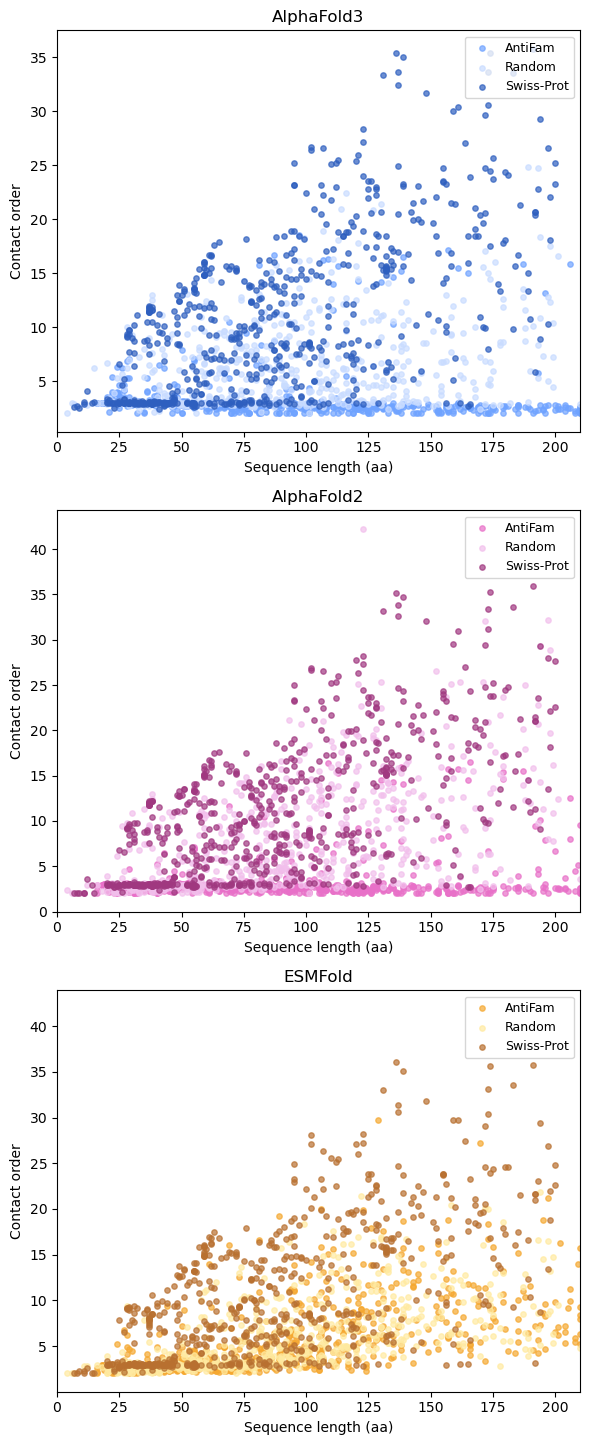

In [70]:
def plot_co_scatter_combined(models):
    """
    models = [
        ("AlphaFold3", af3_antifam_co, af3_random_co, af3_sp_co),
        ("AlphaFold2", af2_antifam_co, af2_random_co, af2_sp_co),
        ("ESMFold",    esm_antifam_co, esm_random_co, esm_sp_co),
    ]
    """
    fig, axes = plt.subplots(
        nrows=len(models),
        ncols=1,
        figsize=(6, 15),
        # sharex=True,
        # sharey=True,
    )

    for ax, (model_name, antifam_co, random_co, swissprot_co) in zip(axes, models):
        print(model_name)
        for gname, co_df, key in [
            ("AntiFam", antifam_co, "AntiFam"),
            ("Random", random_co, "Random"),
            ("Swiss-Prot", swissprot_co, "Swiss-Prot"),
        ]:
            print(co_df.columns)
            print(key)
            ax.scatter(
                co_df["length"],
                co_df["contact_order"],
                s=15,
                c=COLOUR_MAP[model_name][key],
                alpha=0.7,
                label=gname,
            )

        ax.set_xlim(0, 210)
        ax.set_xticks(range(0, 210, 25))
        ax.set_title(model_name, fontsize=12)

        # Each row keeps its own legend
        ax.legend(loc="upper right", fontsize=9)
        ax.set_xlabel("Sequence length (aa)")
        ax.set_ylabel("Contact order")

    # Shared axis labels

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


plot_co_scatter_combined(
    [
        ("AlphaFold3", af3_antifam_co, af3_random_co, af3_sp_co),
        ("AlphaFold2", af2_antifam_co, af2_random_co, af2_sp_co),
        ("ESMFold", esm_antifam_co, esm_random_co, esm_sp_co),
    ]
)



AlphaFold3
  Short (<50 aa)
    AntiFam      n=168  mean=3.26  sd=0.84  med=2.98  IQR=[2.93-3.16]
    Random       n=167  mean=3.71  sd=1.90  med=2.98  IQR=[2.92-3.14]
    Swiss-Prot   n=169  mean=5.20  sd=3.35  med=3.05  IQR=[2.97-8.48]
  Long (≥50 aa)
    AntiFam      n=595  mean=3.19  sd=2.55  med=2.67  IQR=[2.34-2.91]
    Random       n=477  mean=6.63  sd=4.20  med=5.31  IQR=[3.07-9.03]
    Swiss-Prot   n=475  mean=12.64  sd=7.55  med=12.07  IQR=[6.30-17.28]

AlphaFold2
  Short (<50 aa)
    AntiFam      n=168  mean=2.76  sd=0.52  med=2.84  IQR=[2.44-2.96]
    Random       n=167  mean=3.66  sd=2.28  med=2.95  IQR=[2.69-3.04]
    Swiss-Prot   n=169  mean=5.16  sd=3.40  med=3.04  IQR=[2.96-8.28]
  Long (≥50 aa)
    AntiFam      n=595  mean=3.60  sd=3.33  med=2.70  IQR=[2.41-2.99]
    Random       n=477  mean=8.82  sd=6.19  med=6.98  IQR=[3.45-12.63]
    Swiss-Prot   n=475  mean=12.77  sd=7.51  med=12.13  IQR=[6.50-17.24]

ESMFold
  Short (<50 aa)
    AntiFam      n=168  mean=2.82  sd

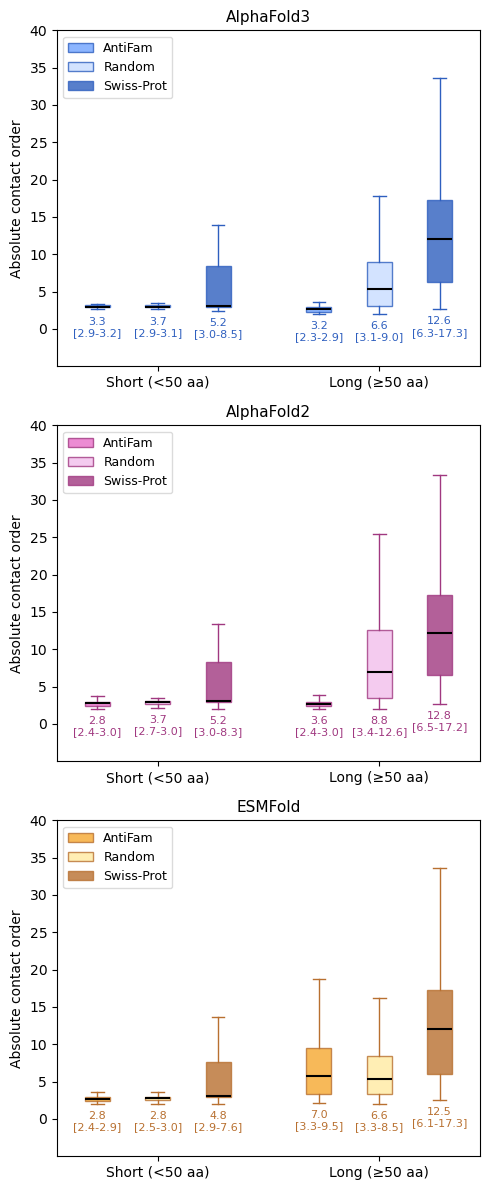

In [71]:
def plot_co_boxplot_short_long_vertical(
    model_data, length_threshold=50, co_col="contact_order"
):
    models = ["AlphaFold3", "AlphaFold2", "ESMFold"]
    sources = ["AntiFam", "Random", "Swiss-Prot"]

    group_names = [
        f"Short (<{length_threshold} aa)",
        f"Long (≥{length_threshold} aa)",
    ]

    y_config = {"ylim": (-5, 40), "yticks": np.linspace(0, 40, 9)}

    box_w, intra, inter = 0.25, 0.6, 2.2
    group_centres = [0, inter]
    model_offsets = [-intra, 0, intra]

    fig, axes = plt.subplots(len(models), 1, figsize=(5, 4 * len(models)), sharey=False)
    if len(models) == 1:
        axes = [axes]

    for ax, (model_name, antifam_co, random_co, sp_co) in zip(axes, model_data):
        source_dfs = {
            "AntiFam": antifam_co,
            "Random": random_co,
            "Swiss-Prot": sp_co,
        }

        print(f"\n{model_name}")
        for gname, filt in [
            (group_names[0], lambda df: df[df["length"] < length_threshold]),
            (group_names[1], lambda df: df[df["length"] >= length_threshold]),
        ]:
            print(f"  {gname}")
            for src in sources:
                df = source_dfs[src]
                if df is None or df.empty:
                    continue
                v = filt(df)[co_col].dropna().values
                q1, q3 = np.percentile(v, [25, 75])
                print(
                    f"    {src:<12} n={len(v)}  mean={np.mean(v):.2f}  sd={np.std(v):.2f}  med={np.median(v):.2f}  IQR=[{q1:.2f}-{q3:.2f}]"
                )

        for g_idx, (gname, filt) in enumerate(
            [
                (group_names[0], lambda df: df[df["length"] < length_threshold]),
                (group_names[1], lambda df: df[df["length"] >= length_threshold]),
            ]
        ):
            for m_idx, src in enumerate(sources):
                df = source_dfs[src]
                if df is None or df.empty:
                    continue
                v = filt(df)[co_col].dropna().values
                pos = group_centres[g_idx] + model_offsets[m_idx]
                mid = COLOUR_MAP[model_name][src]
                dark = COLOUR_MAP[model_name]["Swiss-Prot"]

                bp = ax.boxplot(
                    [v],
                    positions=[pos],
                    widths=box_w,
                    patch_artist=True,
                    showfliers=False,
                    medianprops=dict(color="black", linewidth=1.5),
                    whiskerprops=dict(color=dark, linewidth=1.0),
                    capprops=dict(color=dark, linewidth=1.0),
                )
                bp["boxes"][0].set(facecolor=mid, edgecolor=dark, alpha=0.8)

                q1, q3 = np.percentile(v, [25, 75])
                iqr = q3 - q1
                wlo = max(v.min(), q1 - 1.5 * iqr)

                ax.annotate(
                    f"{np.mean(v):.1f}\n[{q1:.1f}-{q3:.1f}]",
                    xy=(pos, wlo),
                    xytext=(0, -5),
                    textcoords="offset points",
                    ha="center",
                    va="top",
                    fontsize=8,
                    color=dark,
                )

        ax.set_title(model_name, fontsize=11)
        ax.set_xticks(group_centres)
        ax.set_xticklabels(group_names, fontsize=10)
        ax.set_xlim(group_centres[0] - 1.0, group_centres[-1] + 1.0)
        ax.set_ylabel("Absolute contact order", fontsize=10)
        ax.set_ylim(y_config["ylim"])
        ax.set_yticks(y_config["yticks"])

        handles = [
            mpatches.Patch(
                facecolor=COLOUR_MAP[model_name][s],
                edgecolor=COLOUR_MAP[model_name]["Swiss-Prot"],
                alpha=0.8,
                label=s,
            )
            for s in sources
        ]
        ax.legend(
            handles=handles,
            loc="upper left",
            fontsize=9,
            framealpha=0.7,
        )

    # plt.suptitle("Absolute contact order: short vs long sequences", fontsize=12)
    plt.tight_layout()
    # plt.savefig("contact_order_boxplot_vertical.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_co_boxplot_short_long_vertical(
    [
        ("AlphaFold3", af3_antifam_co, af3_random_co, af3_sp_co),
        ("AlphaFold2", af2_antifam_co, af2_random_co, af2_sp_co),
        ("ESMFold", esm_antifam_co, esm_random_co, esm_sp_co),
    ]
)

In [72]:
# def find_af2_msa(root_dir):
#     root, result = Path(root_dir), {}
#     for sub in root.iterdir():
#         if not sub.is_dir():
#             continue
#         for sf in sub.glob("*.a3m"):
#             sid = sf.stem
#             result[sid] = sf
#     return result


# def count_af3_msa_depth(json_path):
#     with open(json_path) as f:
#         data = json.load(f)
#     unpaired, paired = 0, 0
#     for entry in data.get("sequences", []):
#         prot = entry.get("protein", {})
#         if not prot:
#             continue
#         unpaired_msa = prot.get("unpairedMsa", "")
#         paired_msa = prot.get("pairedMsa", "")
#         unpaired += sum(1 for line in unpaired_msa.splitlines() if line.startswith(">"))
#         paired += sum(1 for line in paired_msa.splitlines() if line.startswith(">"))
#     return {"unpaired": unpaired, "paired": paired, "total": unpaired + paired}


# def find_af3_msa(root_dir):
#     root, result = Path(root_dir), {}
#     for batch in root.iterdir():
#         if not batch.is_dir():
#             continue
#         for seq_dir in batch.iterdir():
#             if not seq_dir.is_dir():
#                 continue
#             data_json = seq_dir / f"{seq_dir.name}_data.json"
#             if data_json.exists():
#                 name = seq_dir.name
#                 if re.match(r"^[a-z0-9]+_seq_\d+$", name):
#                     # AntiFam: anf00002_seq_2 -> ANF00002_seq_2
#                     sid = re.sub(
#                         r"^([a-z0-9]+)(_seq_)(\d+)$",
#                         lambda m: m.group(1).upper() + m.group(2) + m.group(3),
#                         name,
#                     )
#                 elif re.match(r"^random_", name):
#                     # Random: keep as-is
#                     sid = name.upper()
#                 else:
#                     # Swiss-Prot: a1js18 -> A1JS18
#                     sid = name.upper()
#                 result.setdefault(sid, data_json)
#     return result


# def count_af2_msa_depth(a3m_path):
#     with open(a3m_path) as f:
#         return sum(1 for line in f if line.startswith(">"))


# def build_msa_depth_df(msa_map, model="af2"):
#     records = []
#     for sid, path in msa_map.items():
#         if model == "af2":
#             depth = count_af2_msa_depth(path)
#             records.append({"uniprot_id": sid, "depth": depth, "model": "AlphaFold2"})
#         else:
#             counts = count_af3_msa_depth(path)
#             records.append(
#                 {
#                     "uniprot_id": sid,
#                     "depth": counts["total"],
#                     "unpaired": counts["unpaired"],
#                     "paired": counts["paired"],
#                     "model": "AlphaFold3",
#                 }
#             )
#     return pd.DataFrame(records)

In [73]:
# # build MSA depth dataframes per group
# def build_all_msa_depths():
#     records = []
#     for group, dir_path in AF2_DIRS.items():
#         msa_map = find_af2_msa(dir_path)
#         for sid, path in msa_map.items():
#             depth = count_af2_msa_depth(path)
#             records.append(
#                 {
#                     "uniprot_id": sid,
#                     "depth": depth,
#                     "group": group,
#                     "model": "AlphaFold2",
#                 }
#             )

#     for group, dir_path in AF3_DIRS.items():
#         msa_map = find_af3_msa(dir_path)
#         for sid, path in msa_map.items():
#             counts = count_af3_msa_depth(path)
#             records.append(
#                 {
#                     "uniprot_id": sid,
#                     "depth": counts["total"],
#                     "unpaired": counts["unpaired"],
#                     "paired": counts["paired"],
#                     "group": group,
#                     "model": "AlphaFold3",
#                 }
#             )

#     return pd.DataFrame(records)


# msa_depth_df = build_all_msa_depths()
# print(msa_depth_df.tail())


In [74]:
# # join with existing pLDDT dataframes
# plddt_dfs = {
#     ("AlphaFold3", "AntiFam"): df_af3,
#     ("AlphaFold2", "AntiFam"): df_colabfold,
#     ("AlphaFold3", "Random"): wrdm_af3,
#     ("AlphaFold2", "Random"): wrdm_colabfold,
#     ("AlphaFold3", "Swiss-Prot"): sp_af3,
#     ("AlphaFold2", "Swiss-Prot"): sp_colabfold,
# }

# msa_plddt_df = []
# for (model, group), df in plddt_dfs.items():
#     depth_subset = msa_depth_df[
#         (msa_depth_df["model"] == model) & (msa_depth_df["group"] == group)
#     ].set_index("uniprot_id")
#     merged = df.join(depth_subset[["depth"]], how="left")
#     merged["group"] = group
#     merged["model"] = model
#     msa_plddt_df.append(merged[["pLDDT mean", "length", "depth", "group", "model"]])

# msa_plddt_df = pd.concat(msa_plddt_df, ignore_index=True)

# print(msa_plddt_df.groupby(["model", "group"])["depth"].describe().round(1))
# print(f"\nMissing depth: {msa_plddt_df['depth'].isna().sum()} / {len(msa_plddt_df)}")

In [75]:
# def plot_msa_depth_vs_plddt(msa_plddt_df):
#     models = ["AlphaFold2", "AlphaFold3"]
#     groups = ["Swiss-Prot"]

#     fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

#     for ax, model in zip(axes, models):
#         df_model = msa_plddt_df[msa_plddt_df["model"] == model].dropna(
#             subset=["depth", "pLDDT mean"]
#         )
#         for group in groups:
#             df_group = df_model[df_model["group"] == group]
#             ax.scatter(
#                 df_group["depth"],
#                 df_group["pLDDT mean"],
#                 s=15,
#                 c=COLOUR_MAP[model][group],
#                 alpha=0.5,
#                 label=group,
#             )
#             # r, p = spearmanr(df_group["depth"], df_group["pLDDT mean"])
#             # print(
#             #     f"{model} | {group}: n={len(df_group)}, Spearman r={r:.3f}, p={p:.4f}"
#             # )

#         ax.set_xscale("log")
#         ax.set_xlabel("MSA depth (log scale)", fontsize=11)
#         ax.set_ylabel("pLDDT mean" if model == "AlphaFold2" else "", fontsize=11)
#         ax.set_yticks(np.linspace(0, 100, 6))
#         ax.set_ylim(0, 100)
#         ax.set_title(model, fontsize=12)
#         ax.legend(loc="lower right", fontsize=9)

#     plt.tight_layout()
#     plt.show()


# plot_msa_depth_vs_plddt(msa_plddt_df)

In [76]:
# def plot_msa_depth_plddt_lines(msa_plddt_df, n_depth_bins=8):
#     models = ["AlphaFold2", "AlphaFold3"]
#     groups = ["AntiFam", "Random", "Swiss-Prot"]

#     fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

#     for ax, model in zip(axes, models):
#         df_model = (
#             msa_plddt_df[msa_plddt_df["model"] == model]
#             .dropna(subset=["depth", "pLDDT mean"])
#             .copy()
#         )

#         # bin msa depth on log scale
#         df_model["depth_bin"] = pd.cut(
#             np.log10(df_model["depth"].clip(lower=1)),
#             bins=n_depth_bins,
#         )
#         bin_mids = df_model.groupby("depth_bin")["depth"].median()

#         for group in groups:
#             df_group = df_model[df_model["group"] == group]
#             grouped = df_group.groupby("depth_bin")["pLDDT mean"]
#             means = grouped.mean()
#             sds = grouped.std()
#             x = bin_mids.reindex(means.index)

#             ax.plot(
#                 x,
#                 means,
#                 color=COLOUR_MAP[model][group],
#                 lw=2,
#                 marker="o",
#                 markersize=5,
#                 label=group,
#             )
#             ax.fill_between(
#                 x,
#                 means - sds,
#                 means + sds,
#                 color=COLOUR_MAP[model][group],
#                 alpha=0.15,
#             )

#         ax.set_xscale("log")
#         ax.set_xlabel("MSA depth (log scale)", fontsize=11)
#         ax.set_ylabel("pLDDT mean" if model == "AlphaFold2" else "", fontsize=11)
#         ax.set_yticks(np.linspace(0, 100, 6))
#         ax.set_ylim(0, 100)
#         ax.set_title(model, fontsize=12)
#         ax.legend(loc="upper left", fontsize=9)
#         # _style_ax(ax)

#     plt.tight_layout()
#     plt.show()


# plot_msa_depth_plddt_lines(msa_plddt_df)

In [77]:
# sps_msa = msa_plddt_df[msa_plddt_df["group"] == "Swiss-Prot"]
# low_plddt_msa = sps_msa[sps_msa["pLDDT mean"] < 50]
# print(low_plddt_msa)

In [78]:
# for path, title in [
#     ("part1_refoldunfold/1.5_disorder_check/seed_seqs_colabfold_iupred.csv", "AntiFam"),
#     ("part1_refoldunfold/1.5_disorder_check/sp_res_colabfold_iupred.csv", "Swiss-Prot"),
# ]:
#     df_iupred = pd.read_csv(path, index_col=0)
#     fig, ax = plt.subplots(figsize=(6, 5))
#     ax.scatter(
#         df_iupred["iupred_average"],
#         df_iupred["pLDDT mean"],
#         s=15,
#         c=COLOUR_MAP["AlphaFold2"]["AntiFam"],
#         alpha=0.4,
#         edgecolors=COLOUR_MAP["AlphaFold2"]["Swiss-Prot"],
#         linewidths=0.3,
#     )
#     ax.set_xlabel("IUPred average disorder score")
#     ax.set_ylabel("pLDDT mean")
#     ax.set_xlim(0, 1)
#     ax.set_ylim(0, 100)
#     ax.set_title(f"AlphaFold2: IUPred disorder vs pLDDT ({title})")
#     plt.tight_layout()
#     plt.show()